<a href="https://colab.research.google.com/github/brunamportoDS/wids-datathon-2026/blob/main/wids_feature_engineering_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WiDS Datathon 2026: Feature Engineering & Modeling

**Predicting Wildfire Threat to Evacuation Zones Using Survival Analysis**

This notebook covers the complete modeling pipeline: feature engineering, model evaluation, calibration experiments, ensemble optimization, and final submission generation.

**Best Leaderboard Score: 0.9663** (82% Risk+Platt + 18% Cox PH)

## 1. Setup & Dependencies

Install scikit-survival with pinned versions to avoid compatibility issues. **Run this cell, restart the session, then skip to Section 2.**

In [ ]:
# THIS MUST BE THE FIRST CELL — run it, then restart session
!pip install scikit-survival==0.23.1 scikit-learn==1.5.2 numpy==1.26.4 --force-reinstall -q
print('Done. Now restart session, skip this cell, run from cell 2.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.8/345.8 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 150.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports & Data Loading

Load the competition data and import all required libraries.

In [ ]:
# ============================================================
# WiDS Datathon 2026: Predicting Wildfire Threat to Evacuation Zones
# 02 — Feature Engineering & Modeling
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

feature_cols = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]

print(f'Train: {train.shape}, Test: {test.shape}')

Train: (221, 37), Test: (95, 35)


## 3. Feature Engineering

16 features engineered from 34 raw inputs, informed by EDA findings:

- **Binary indicators (5):** Convert sparse features into presence/absence flags. Fires with growth hit at 71% vs 26% without — the binary signal is stronger than the raw values.
- **Distance transforms (2):** Log transform compresses the extreme range (0–750km). Distance in km for interpretability.
- **Interaction features (3):** Capture fire dynamics relative to proximity. Close + aligned fires hit at 76% vs close + unaligned at 52%.
- **Temporal flags (2):** Afternoon start and summer season indicators.

5 features capture 97% of full performance, confirming signal concentration.

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Informed by EDA findings:
# 1. Binary indicators for sparse features (71% vs 26% hit rate)
# 2. Log transform for distance (compress long tail)
# 3. Distance × alignment interaction (76% hit rate when close + aligned)
# 4. Temporal flags

def engineer_features(df):
    """Apply feature engineering to train or test dataframe."""
    df = df.copy()

    # --- Binary indicators (from sparsity analysis) ---
    df['has_growth'] = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['has_movement'] = (df['centroid_displacement_m'] > 0).astype(int)
    df['has_closing_speed'] = (df['closing_speed_m_per_h'] > 0).astype(int)
    df['has_alignment'] = (df['alignment_abs'] > 0).astype(int)
    df['has_distance_change'] = (df['dist_change_ci_0_5h'] > 0).astype(int)

    # --- Distance transforms ---
    df['log_dist'] = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_km'] = df['dist_min_ci_0_5h'] / 1000

    # --- Interaction features ---
    df['alignment_over_dist'] = df['alignment_abs'] / (df['dist_min_ci_0_5h'] + 1)
    df['closing_over_dist'] = df['closing_speed_abs_m_per_h'] / (df['dist_min_ci_0_5h'] + 1)
    df['growth_over_dist'] = df['area_growth_rate_ha_per_h'] / (df['dist_min_ci_0_5h'] + 1)

    # --- Temporal flags ---
    df['is_afternoon'] = ((df['event_start_hour'] >= 12) & (df['event_start_hour'] <= 17)).astype(int)
    df['is_summer'] = df['event_start_month'].isin([6, 7, 8, 9]).astype(int)

    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

# Define feature sets
new_features = ['has_growth', 'has_movement', 'has_closing_speed', 'has_alignment',
                'has_distance_change', 'log_dist', 'dist_km', 'alignment_over_dist',
                'closing_over_dist', 'growth_over_dist', 'is_afternoon', 'is_summer']

all_features = feature_cols + new_features

print(f'Original features: {len(feature_cols)}')
print(f'New features: {len(new_features)}')
print(f'Total features: {len(all_features)}')

Original features: 34
New features: 12
Total features: 46


## 4. Evaluation Functions

The competition metric is:

**Hybrid Score = 0.3 × C-index + 0.7 × (1 − Weighted Brier Score)**

Weighted Brier = 0.3 × Brier@24h + 0.4 × Brier@48h + 0.3 × Brier@72h

Calibration (Brier) accounts for 70% of the score — getting probabilities *right* matters more than getting the *ranking* right. The 48h horizon carries the most individual weight (28% of total).

In [ ]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================
# Hybrid Score = 0.3 × C-index + 0.7 × (1 − Weighted Brier Score)

def concordance_index(time, event, predictions):
    """
    Compute C-index: probability that for a random pair,
    the fire that hit sooner gets a higher predicted probability.
    Uses prob_72h as the risk score for ranking.
    """
    n = len(time)
    concordant = 0
    discordant = 0
    tied = 0

    for i in range(n):
        for j in range(i + 1, n):
            # Only consider pairs where at least one is an event
            if event[i] == 0 and event[j] == 0:
                continue
            # Determine which should have higher risk
            if event[i] == 1 and event[j] == 1:
                if time[i] < time[j]:
                    if predictions[i] > predictions[j]:
                        concordant += 1
                    elif predictions[i] < predictions[j]:
                        discordant += 1
                    else:
                        tied += 1
                elif time[j] < time[i]:
                    if predictions[j] > predictions[i]:
                        concordant += 1
                    elif predictions[j] < predictions[i]:
                        discordant += 1
                    else:
                        tied += 1
            elif event[i] == 1 and event[j] == 0:
                if time[i] < time[j]:
                    if predictions[i] > predictions[j]:
                        concordant += 1
                    elif predictions[i] < predictions[j]:
                        discordant += 1
                    else:
                        tied += 1
            elif event[j] == 1 and event[i] == 0:
                if time[j] < time[i]:
                    if predictions[j] > predictions[i]:
                        concordant += 1
                    elif predictions[j] < predictions[i]:
                        discordant += 1
                    else:
                        tied += 1

    total = concordant + discordant + tied
    if total == 0:
        return 0.5
    return (concordant + 0.5 * tied) / total


def censor_aware_brier(time, event, pred_prob, horizon):
    """
    Censor-aware Brier score at a specific horizon.
    - Hits by horizon: true label = 1
    - Censored after horizon: true label = 0
    - Censored before horizon: excluded
    """
    mask = np.ones(len(time), dtype=bool)
    true_labels = np.zeros(len(time))

    for i in range(len(time)):
        if event[i] == 1 and time[i] <= horizon:
            true_labels[i] = 1  # hit by this horizon
        elif event[i] == 1 and time[i] > horizon:
            true_labels[i] = 0  # hit but after this horizon
        elif event[i] == 0 and time[i] >= horizon:
            true_labels[i] = 0  # censored after horizon (survived)
        else:
            mask[i] = False  # censored before horizon — exclude

    if mask.sum() == 0:
        return 0.0

    return np.mean((pred_prob[mask] - true_labels[mask]) ** 2)


def hybrid_score(time, event, prob_24h, prob_48h, prob_72h):
    """
    Competition metric:
    Hybrid = 0.3 × C-index + 0.7 × (1 − Weighted Brier)
    Weighted Brier = 0.3 × Brier@24h + 0.4 × Brier@48h + 0.3 × Brier@72h
    """
    # C-index uses prob_72h as risk score
    c_idx = concordance_index(time, event, prob_72h)

    # Weighted Brier
    b24 = censor_aware_brier(time, event, prob_24h, 24)
    b48 = censor_aware_brier(time, event, prob_48h, 48)
    b72 = censor_aware_brier(time, event, prob_72h, 72)
    weighted_brier = 0.3 * b24 + 0.4 * b48 + 0.3 * b72

    hybrid = 0.3 * c_idx + 0.7 * (1 - weighted_brier)

    return {
        'hybrid': hybrid,
        'c_index': c_idx,
        'weighted_brier': weighted_brier,
        'brier_24h': b24,
        'brier_48h': b48,
        'brier_72h': b72
    }


# Quick test with naive baseline
hits = train[train['event'] == 1]['time_to_hit_hours']
naive_probs = {t: (hits <= t).sum() / len(train) for t in [12, 24, 48, 72]}

result = hybrid_score(
    train['time_to_hit_hours'].values,
    train['event'].values,
    np.full(len(train), naive_probs[24]),
    np.full(len(train), naive_probs[48]),
    np.full(len(train), naive_probs[72])
)

print('=== Naive Baseline (predict overall rates for everyone) ===')
for k, v in result.items():
    print(f'  {k:<20s}: {v:.4f}')
print(f'\nThis is our floor to beat.')

=== Naive Baseline (predict overall rates for everyone) ===
  hybrid              : 0.6348
  c_index             : 0.5000
  weighted_brier      : 0.3075
  brier_24h           : 0.2194
  brier_48h           : 0.2493
  brier_72h           : 0.4730

This is our floor to beat.


## 5. Baseline Models

### 5.1 Logistic Regression

Four independent classifiers, one per horizon. Uses censor-aware binary targets (excluding observations censored before each horizon). This establishes a non-survival baseline.

In [ ]:
# ============================================================
# BASELINE: LOGISTIC REGRESSION (4 separate models)
# ============================================================
from sklearn.linear_model import LogisticRegression

# Create binary targets for each horizon
for t in [12, 24, 48, 72]:
    train_fe[f'hit_by_{t}h'] = ((train_fe['event'] == 1) & (train_fe['time_to_hit_hours'] <= t)).astype(int)

# Use a curated feature set (avoid highly sparse raw features)
core_features = [
    'dist_min_ci_0_5h', 'log_dist', 'alignment_abs', 'has_alignment',
    'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h',
    'has_growth', 'has_movement', 'log1p_area_first', 'log1p_growth',
    'spread_bearing_cos', 'alignment_over_dist', 'is_afternoon',
    'area_first_ha', 'event_start_month'
]

# Cross-validated evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    preds = {}
    for t in [12, 24, 48, 72]:
        model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        model.fit(X_tr, tr[f'hit_by_{t}h'])
        preds[t] = model.predict_proba(X_va)[:, 1]

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Logistic Regression Baseline (5-fold CV) ===')
mean_hybrid = np.mean([s['hybrid'] for s in cv_scores])
std_hybrid = np.std([s['hybrid'] for s in cv_scores])
print(f'Hybrid Score: {mean_hybrid:.4f} ± {std_hybrid:.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in cv_scores]):.4f}')

Fold 0: Hybrid=0.9561  C-idx=0.9335  Brier=0.0341
Fold 1: Hybrid=0.9238  C-idx=0.9036  Brier=0.0675
Fold 2: Hybrid=0.9148  C-idx=0.8953  Brier=0.0768
Fold 3: Hybrid=0.9603  C-idx=0.9229  Brier=0.0237
Fold 4: Hybrid=0.9562  C-idx=0.9392  Brier=0.0365

=== Logistic Regression Baseline (5-fold CV) ===
Hybrid Score: 0.9422 ± 0.0190
C-index:      0.9189
Wtd Brier:    0.0478


### 5.2 Survival Model Imports

In [ ]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# Create survival target (structured array required by scikit-survival)
y_surv = Surv.from_arrays(
    event=train_fe['event'].astype(bool),
    time=train_fe['time_to_hit_hours']
)

# Time horizons for prediction
horizons = [12, 24, 48, 72]

print(f'Survival target created: {len(y_surv)} observations')
print(f'Events: {train_fe["event"].sum()}, Censored: {(train_fe["event"]==0).sum()}')

Survival target created: 221 observations
Events: 69, Censored: 152


### 5.3 Cox Proportional Hazards

Linear survival model that estimates the effect of covariates on the hazard function without specifying the baseline hazard. Assumes proportional hazards — the effect of each feature is constant over time.

Strengths: interpretable coefficients, handles censoring natively, produces monotonic survival curves.
Weakness: linearity assumption limits expressiveness.

In [ ]:
# ============================================================
# Cox PH with cross-validation
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cox_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    # Create survival targets for this fold
    y_tr = Surv.from_arrays(
        event=tr['event'].astype(bool),
        time=tr['time_to_hit_hours']
    )
    y_va = Surv.from_arrays(
        event=va['event'].astype(bool),
        time=va['time_to_hit_hours']
    )

    # Scale features
    scaler = StandardScaler()
    X_tr = pd.DataFrame(scaler.fit_transform(tr[core_features]),
                         columns=core_features, index=tr.index)
    X_va = pd.DataFrame(scaler.transform(va[core_features]),
                         columns=core_features, index=va.index)

    # Fit Cox PH
    cox = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    try:
        cox.fit(X_tr, y_tr)

        # Get survival function for each validation observation
        surv_funcs = cox.predict_survival_function(X_va)

        # Extract P(hit by T) = 1 - S(T) at each horizon
        preds = {}
        for t in horizons:
            probs = []
            for sf in surv_funcs:
                # Find probability of event by time t
                # S(t) = probability of surviving past t
                # P(hit by t) = 1 - S(t)
                if t <= sf.x[-1]:
                    prob = 1 - sf(t)
                else:
                    prob = 1 - sf(sf.x[-1])
                probs.append(np.clip(prob, 0, 1))
            preds[t] = np.array(probs)

        # Monotonicity is guaranteed by survival curves, but enforce just in case
        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        score = hybrid_score(
            va['time_to_hit_hours'].values,
            va['event'].values,
            preds[24], preds[48], preds[72]
        )
        score['fold'] = fold
        cox_cv_scores.append(score)
        print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
              f'Brier={score["weighted_brier"]:.4f}')

    except Exception as e:
        print(f'Fold {fold}: FAILED — {e}')

if cox_cv_scores:
    print(f'\n=== Cox PH (5-fold CV) ===')
    print(f'Hybrid Score: {np.mean([s["hybrid"] for s in cox_cv_scores]):.4f} '
          f'± {np.std([s["hybrid"] for s in cox_cv_scores]):.4f}')
    print(f'C-index:      {np.mean([s["c_index"] for s in cox_cv_scores]):.4f}')
    print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in cox_cv_scores]):.4f}')

Fold 0: Hybrid=0.9709  C-idx=0.9393  Brier=0.0156
Fold 1: Hybrid=0.9232  C-idx=0.9114  Brier=0.0718
Fold 2: Hybrid=0.9163  C-idx=0.9017  Brier=0.0774
Fold 3: Hybrid=0.9731  C-idx=0.9615  Brier=0.0219
Fold 4: Hybrid=0.9565  C-idx=0.9151  Brier=0.0257

=== Cox PH (5-fold CV) ===
Hybrid Score: 0.9480 ± 0.0239
C-index:      0.9258
Wtd Brier:    0.0425


### 5.4 Random Survival Forest

Non-parametric ensemble of survival trees. Each tree splits on features that maximize the difference between daughter nodes' survival curves (log-rank splitting).

Strengths: captures non-linear effects, no proportional hazards assumption.
Weakness: can overfit on small datasets (221 rows).

In [ ]:
# ============================================================
# Random Survival Forest
# ============================================================

rsf_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])
    y_va = Surv.from_arrays(event=va['event'].astype(bool), time=va['time_to_hit_hours'])

    X_tr = tr[core_features].values
    X_va = va[core_features].values

    # Random Survival Forest — conservative settings for small dataset
    rsf = RandomSurvivalForest(
        n_estimators=200,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_tr, y_tr)

    # Get survival functions
    surv_funcs = rsf.predict_survival_function(X_va)

    preds = {}
    for t in horizons:
        probs = []
        for sf in surv_funcs:
            if t <= sf.x[-1]:
                prob = 1 - sf(t)
            else:
                prob = 1 - sf(sf.x[-1])
            probs.append(np.clip(prob, 0, 1))
        preds[t] = np.array(probs)

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    rsf_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Random Survival Forest (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in rsf_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in rsf_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in rsf_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in rsf_cv_scores]):.4f}')

Fold 0: Hybrid=0.9734  C-idx=0.9217  Brier=0.0045
Fold 1: Hybrid=0.9552  C-idx=0.9170  Brier=0.0285
Fold 2: Hybrid=0.9390  C-idx=0.8846  Brier=0.0377
Fold 3: Hybrid=0.9780  C-idx=0.9412  Brier=0.0063
Fold 4: Hybrid=0.9723  C-idx=0.9455  Brier=0.0162

=== Random Survival Forest (5-fold CV) ===
Hybrid Score: 0.9636 ± 0.0145
C-index:      0.9220
Wtd Brier:    0.0186


### 5.5 Model Comparison Summary

Compare all models evaluated so far.

In [ ]:
# ============================================================
# MODEL COMPARISON SUMMARY
# ============================================================

print('=== Model Comparison (5-fold CV) ===\n')
print(f'{"Model":<30s} {"Hybrid":>10s} {"C-index":>10s} {"Wtd Brier":>10s}')
print('-' * 62)
print(f'{"Naive Baseline":<30s} {"0.6348":>10s} {"0.5000":>10s} {"0.3075":>10s}')

print(f'{"Logistic Regression":<30s} '
      f'{np.mean([s["hybrid"] for s in cv_scores]):>10.4f} '
      f'{np.mean([s["c_index"] for s in cv_scores]):>10.4f} '
      f'{np.mean([s["weighted_brier"] for s in cv_scores]):>10.4f}')

if cox_cv_scores:
    print(f'{"Cox PH":<30s} '
          f'{np.mean([s["hybrid"] for s in cox_cv_scores]):>10.4f} '
          f'{np.mean([s["c_index"] for s in cox_cv_scores]):>10.4f} '
          f'{np.mean([s["weighted_brier"] for s in cox_cv_scores]):>10.4f}')

print(f'{"Random Survival Forest":<30s} '
      f'{np.mean([s["hybrid"] for s in rsf_cv_scores]):>10.4f} '
      f'{np.mean([s["c_index"] for s in rsf_cv_scores]):>10.4f} '
      f'{np.mean([s["weighted_brier"] for s in rsf_cv_scores]):>10.4f}')

=== Model Comparison (5-fold CV) ===

Model                              Hybrid    C-index  Wtd Brier
--------------------------------------------------------------
Naive Baseline                     0.6348     0.5000     0.3075
Logistic Regression                0.9422     0.9189     0.0478
Cox PH                             0.9480     0.9258     0.0425
Random Survival Forest             0.9636     0.9220     0.0186


### 5.6 First Submission (RSF Baseline)

Generate the initial Kaggle submission using Random Survival Forest.

In [ ]:
# ============================================================
# GENERATE FINAL SUBMISSION
# ============================================================
# Strategy: Train RSF on full training data, predict on test set

# Full training survival target
y_full = Surv.from_arrays(
    event=train_fe['event'].astype(bool),
    time=train_fe['time_to_hit_hours']
)

X_train_full = train_fe[core_features].values
X_test_final = test_fe[core_features].values

# Train final RSF model
rsf_final = RandomSurvivalForest(
    n_estimators=200,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rsf_final.fit(X_train_full, y_full)
print('Final RSF model trained on full training data.')

# Predict survival functions for test set
surv_funcs_test = rsf_final.predict_survival_function(X_test_final)

# Extract probabilities at each horizon
submission = sub.copy()
for t in [12, 24, 48, 72]:
    probs = []
    for sf in surv_funcs_test:
        if t <= sf.x[-1]:
            prob = 1 - sf(t)
        else:
            prob = 1 - sf(sf.x[-1])
        probs.append(np.clip(prob, 0, 1))
    submission[f'prob_{t}h'] = probs

# Enforce monotonicity
for i in range(len(submission)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission.loc[i, f'prob_{t2}h'] < submission.loc[i, f'prob_{t1}h']:
            submission.loc[i, f'prob_{t2}h'] = submission.loc[i, f'prob_{t1}h']

# Validate submission
print('\n=== Submission Validation ===')
print(f'Shape: {submission.shape} (expected: {sub.shape})')
print(f'Columns: {list(submission.columns)}')
print(f'IDs match: {(submission["event_id"] == sub["event_id"]).all()}')
print(f'All probs in [0,1]: {(submission[["prob_12h","prob_24h","prob_48h","prob_72h"]] >= 0).all().all() and (submission[["prob_12h","prob_24h","prob_48h","prob_72h"]] <= 1).all().all()}')

# Check monotonicity
mono_ok = True
for i in range(len(submission)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission.loc[i, f'prob_{t2}h'] < submission.loc[i, f'prob_{t1}h']:
            mono_ok = False
print(f'Monotonicity: {"PASS" if mono_ok else "FAIL"}')

print('\n=== Prediction Summary ===')
for t in [12, 24, 48, 72]:
    col = f'prob_{t}h'
    print(f'  prob_{t}h: mean={submission[col].mean():.3f}  '
          f'median={submission[col].median():.3f}  '
          f'min={submission[col].min():.3f}  max={submission[col].max():.3f}')

print('\n=== Sample Predictions ===')
print(submission.head(10).to_string(index=False))

Final RSF model trained on full training data.

=== Submission Validation ===
Shape: (95, 5) (expected: (95, 5))
Columns: ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
IDs match: True
All probs in [0,1]: True
Monotonicity: PASS

=== Prediction Summary ===
  prob_12h: mean=0.187  median=0.012  min=0.003  max=0.963
  prob_24h: mean=0.264  median=0.023  min=0.006  max=0.973
  prob_48h: mean=0.283  median=0.026  min=0.007  max=0.986
  prob_72h: mean=0.307  median=0.044  min=0.014  max=0.991

=== Sample Predictions ===
 event_id  prob_12h  prob_24h  prob_48h  prob_72h
 10662602  0.011708  0.024444  0.026364  0.058777
 13353600  0.536746  0.850421  0.912974  0.947228
 13942327  0.013167  0.024957  0.026977  0.058364
 16112781  0.543438  0.854381  0.896630  0.935348
 17132808  0.187331  0.188839  0.189153  0.189153
 17445696  0.008202  0.015962  0.016930  0.030075
 17599982  0.019746  0.036962  0.038454  0.062463
 18750374  0.448586  0.720367  0.781897  0.863461
 21365245  0.00

In [ ]:
# Save submission
submission.to_csv('submission_rsf.csv', index=False)
print('Submission saved to submission_rsf.csv')
print('Upload this file to Kaggle!')

Submission saved to submission_rsf.csv
Upload this file to Kaggle!


### 5.7 Visualize Survival Curves

Plot sample survival curves to verify the model produces reasonable, monotonically decreasing survival functions.

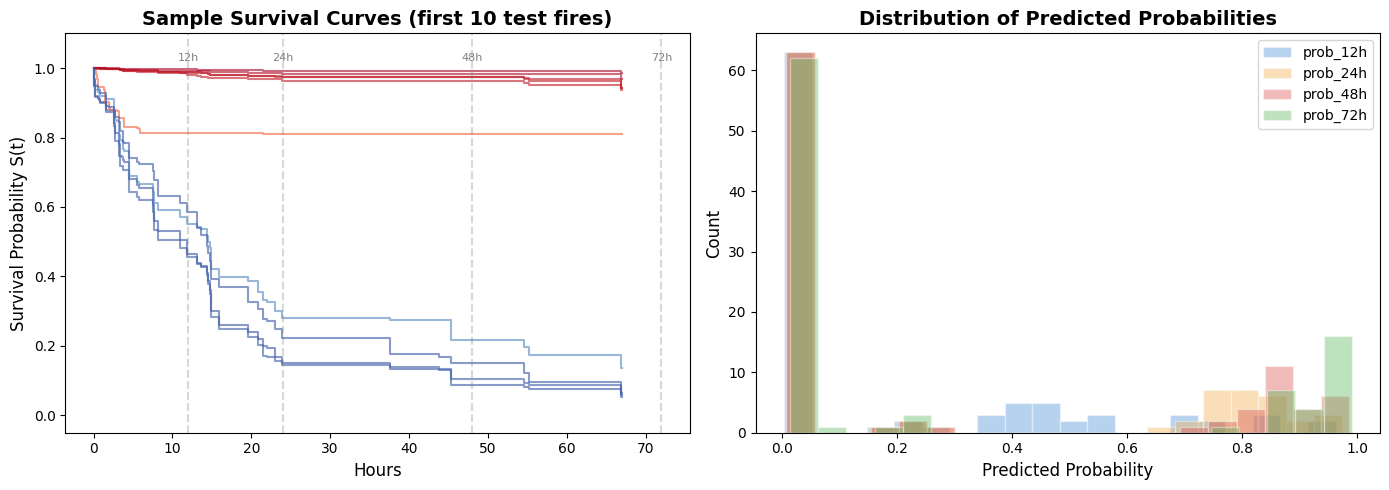

In [ ]:
# ============================================================
# VISUALIZE: Sample Survival Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot a few survival curves from test set
n_show = 10
for i in range(n_show):
    sf = surv_funcs_test[i]
    color = plt.cm.RdYlBu(submission.iloc[i]['prob_72h'])
    axes[0].step(sf.x, sf.y, where='post', alpha=0.6, color=color)

for t in [12, 24, 48, 72]:
    axes[0].axvline(t, color='gray', linestyle='--', alpha=0.3)
    axes[0].text(t, 1.02, f'{t}h', ha='center', fontsize=8, color='gray')

axes[0].set_xlabel('Hours', fontsize=12)
axes[0].set_ylabel('Survival Probability S(t)', fontsize=12)
axes[0].set_title(f'Sample Survival Curves (first {n_show} test fires)', fontweight='bold', fontsize=14)
axes[0].set_ylim(-0.05, 1.1)

# Distribution of predicted probabilities
for t, color in [(12, '#4a90d9'), (24, '#f0ad4e'), (48, '#d9534f'), (72, '#5cb85c')]:
    axes[1].hist(submission[f'prob_{t}h'], bins=20, alpha=0.4, color=color,
                 label=f'prob_{t}h', edgecolor='white')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Predicted Probabilities', fontweight='bold', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.8 Gradient Boosting Survival Analysis

Boosted ensemble of survival trees. Sequentially fits trees to the negative gradient of the loss function (partial likelihood for Cox-based, or other survival losses).

This became our strongest individual model (CV Hybrid: 0.974). Key hyperparameter finding: **shallow trees (max_depth=2-3) consistently outperform deeper models** on 221 rows.

In [ ]:
# ============================================================
# GRADIENT BOOSTING SURVIVAL ANALYSIS
# ============================================================
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

gbs_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    gbs = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
    gbs.fit(X_tr, y_tr)

    surv_funcs = gbs.predict_survival_function(X_va)

    preds = {}
    for t in horizons:
        probs = []
        for sf in surv_funcs:
            if t <= sf.x[-1]:
                prob = 1 - sf(t)
            else:
                prob = 1 - sf(sf.x[-1])
            probs.append(np.clip(prob, 0, 1))
        preds[t] = np.array(probs)

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    gbs_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Gradient Boosting Survival (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in gbs_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in gbs_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in gbs_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in gbs_cv_scores]):.4f}')

Fold 0: Hybrid=0.9857  C-idx=0.9560  Brier=0.0015
Fold 1: Hybrid=0.9693  C-idx=0.9462  Brier=0.0208
Fold 2: Hybrid=0.9525  C-idx=0.9380  Brier=0.0413
Fold 3: Hybrid=0.9861  C-idx=0.9594  Brier=0.0025
Fold 4: Hybrid=0.9736  C-idx=0.9476  Brier=0.0152

=== Gradient Boosting Survival (5-fold CV) ===
Hybrid Score: 0.9734 ± 0.0124
C-index:      0.9494
Wtd Brier:    0.0163


## 6. Hyperparameter Tuning

### 6.1 Random Survival Forest Tuning

Grid search over tree depth, number of estimators, and leaf sizes. With 221 rows, regularization is critical — deeper trees memorize the training data.

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING: Random Survival Forest
# ============================================================
from itertools import product

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, None],
    'min_samples_leaf': [3, 5, 10],
}

best_score = 0
best_params = {}
results = []

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'])
count = 0

for n_est, depth, leaf in product(param_grid['n_estimators'],
                                   param_grid['max_depth'],
                                   param_grid['min_samples_leaf']):
    count += 1
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]

        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        rsf_tune = RandomSurvivalForest(
            n_estimators=n_est,
            max_depth=depth,
            min_samples_split=10,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        )
        rsf_tune.fit(tr[core_features].values, y_tr)
        surv_funcs = rsf_tune.predict_survival_function(va[core_features].values)

        preds = {}
        for t in horizons:
            probs = []
            for sf in surv_funcs:
                if t <= sf.x[-1]:
                    prob = 1 - sf(t)
                else:
                    prob = 1 - sf(sf.x[-1])
                probs.append(np.clip(prob, 0, 1))
            preds[t] = np.array(probs)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s['hybrid'])

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    results.append({
        'n_estimators': n_est, 'max_depth': depth,
        'min_samples_leaf': leaf, 'hybrid': mean_score, 'std': std_score
    })

    if mean_score > best_score:
        best_score = mean_score
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_leaf': leaf}

    if count % 6 == 0 or count == total:
        print(f'Progress: {count}/{total} combinations tested...')

print(f'\n=== Best RSF Parameters ===')
print(f'Parameters: {best_params}')
print(f'Hybrid Score: {best_score:.4f}')

# Show top 5 configurations
results_df = pd.DataFrame(results).sort_values('hybrid', ascending=False)
print(f'\n=== Top 5 Configurations ===')
print(results_df.head(10).to_string(index=False))

Progress: 6/36 combinations tested...
Progress: 12/36 combinations tested...
Progress: 18/36 combinations tested...
Progress: 24/36 combinations tested...
Progress: 30/36 combinations tested...
Progress: 36/36 combinations tested...

=== Best RSF Parameters ===
Parameters: {'n_estimators': 200, 'max_depth': 4, 'min_samples_leaf': 3}
Hybrid Score: 0.9649

=== Top 5 Configurations ===
 n_estimators  max_depth  min_samples_leaf   hybrid      std
          200        4.0                 3 0.964874 0.015130
          500        4.0                 3 0.964858 0.014961
          100        6.0                 3 0.964659 0.015784
          500        6.0                 3 0.964283 0.013539
          500        4.0                 5 0.963964 0.014958
          100        NaN                 5 0.963812 0.012338
          200        4.0                 5 0.963561 0.014524
          100        4.0                 5 0.963555 0.015427
          100        NaN                 3 0.963082 0.012856
    

### 6.2 Gradient Boosting Survival Tuning (v1)

Systematic search across depth, learning rate, subsample ratio, and leaf constraints. Key finding: **max_depth=2 with min_samples_leaf=10** is the sweet spot.

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING: Gradient Boosting Survival
# ============================================================
from itertools import product

gbs_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_leaf': [3, 5, 10],
}

gbs_best_score = 0
gbs_best_params = {}
gbs_results = []

total = (len(gbs_param_grid['n_estimators']) * len(gbs_param_grid['max_depth']) *
         len(gbs_param_grid['learning_rate']) * len(gbs_param_grid['min_samples_leaf']))
count = 0

for n_est, depth, lr, leaf in product(gbs_param_grid['n_estimators'],
                                       gbs_param_grid['max_depth'],
                                       gbs_param_grid['learning_rate'],
                                       gbs_param_grid['min_samples_leaf']):
    count += 1
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]

        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        gbs_tune = GradientBoostingSurvivalAnalysis(
            n_estimators=n_est,
            max_depth=depth,
            learning_rate=lr,
            min_samples_split=10,
            min_samples_leaf=leaf,
            subsample=0.8,
            random_state=42
        )
        gbs_tune.fit(X_tr, y_tr)
        surv_funcs = gbs_tune.predict_survival_function(X_va)

        preds = {}
        for t in horizons:
            probs = []
            for sf in surv_funcs:
                if t <= sf.x[-1]:
                    prob = 1 - sf(t)
                else:
                    prob = 1 - sf(sf.x[-1])
                probs.append(np.clip(prob, 0, 1))
            preds[t] = np.array(probs)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s['hybrid'])

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    gbs_results.append({
        'n_estimators': n_est, 'max_depth': depth,
        'learning_rate': lr, 'min_samples_leaf': leaf,
        'hybrid': mean_score, 'std': std_score
    })

    if mean_score > gbs_best_score:
        gbs_best_score = mean_score
        gbs_best_params = {'n_estimators': n_est, 'max_depth': depth,
                           'learning_rate': lr, 'min_samples_leaf': leaf}

    if count % 15 == 0 or count == total:
        print(f'Progress: {count}/{total} — current best: {gbs_best_score:.4f}')

print(f'\n=== Best GBS Parameters ===')
print(f'Parameters: {gbs_best_params}')
print(f'Hybrid Score: {gbs_best_score:.4f}')

gbs_results_df = pd.DataFrame(gbs_results).sort_values('hybrid', ascending=False)
print(f'\n=== Top 10 Configurations ===')
print(gbs_results_df.head(10).to_string(index=False))

Progress: 15/81 — current best: 0.9740
Progress: 30/81 — current best: 0.9740
Progress: 45/81 — current best: 0.9754
Progress: 60/81 — current best: 0.9754
Progress: 75/81 — current best: 0.9754
Progress: 81/81 — current best: 0.9754

=== Best GBS Parameters ===
Parameters: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.1, 'min_samples_leaf': 5}
Hybrid Score: 0.9754

=== Top 10 Configurations ===
 n_estimators  max_depth  learning_rate  min_samples_leaf   hybrid      std
          100          2           0.10                 5 0.975415 0.012338
          100          2           0.10                10 0.975312 0.011717
          200          2           0.10                10 0.975207 0.012793
          100          2           0.20                10 0.974932 0.012649
          200          2           0.05                 5 0.974473 0.011972
          100          2           0.10                 3 0.974460 0.011780
          200          2           0.05                10 

### 6.3 Gradient Boosting Survival Tuning (v2)

Broader search with subsample variation. Confirms shallow trees dominate.

In [ ]:
# ============================================================
# GBS TUNING v2: Broader search with subsample variation
# ============================================================

gbs_param_grid_v2 = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [1, 2, 3],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [5, 10, 15],
}

# Too many combos for full grid (720), so we'll do randomized search
from itertools import product
import random

random.seed(42)
all_combos = list(product(
    gbs_param_grid_v2['n_estimators'],
    gbs_param_grid_v2['max_depth'],
    gbs_param_grid_v2['learning_rate'],
    gbs_param_grid_v2['subsample'],
    gbs_param_grid_v2['min_samples_leaf']
))
# Sample 100 random combinations
sampled_combos = random.sample(all_combos, min(100, len(all_combos)))

gbs_v2_best_score = 0
gbs_v2_best_params = {}
gbs_v2_results = []

for idx, (n_est, depth, lr, sub_s, leaf) in enumerate(sampled_combos):
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]

        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        gbs_v2 = GradientBoostingSurvivalAnalysis(
            n_estimators=n_est, max_depth=depth, learning_rate=lr,
            min_samples_split=10, min_samples_leaf=leaf,
            subsample=sub_s, random_state=42
        )
        gbs_v2.fit(X_tr, y_tr)
        surv_funcs = gbs_v2.predict_survival_function(X_va)

        preds = {}
        for t in horizons:
            probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                     for sf in surv_funcs]
            preds[t] = np.array(probs)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s['hybrid'])

    mean_score = np.mean(fold_scores)
    gbs_v2_results.append({
        'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr,
        'subsample': sub_s, 'min_samples_leaf': leaf,
        'hybrid': mean_score, 'std': np.std(fold_scores)
    })

    if mean_score > gbs_v2_best_score:
        gbs_v2_best_score = mean_score
        gbs_v2_best_params = {
            'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr,
            'subsample': sub_s, 'min_samples_leaf': leaf
        }

    if (idx + 1) % 20 == 0 or idx == len(sampled_combos) - 1:
        print(f'Progress: {idx+1}/{len(sampled_combos)} — best: {gbs_v2_best_score:.4f}')

print(f'\n=== Best GBS v2 Parameters ===')
print(f'Parameters: {gbs_v2_best_params}')
print(f'Hybrid Score: {gbs_v2_best_score:.4f}')
print(f'Previous best: 0.9755')
print(f'Improvement: {gbs_v2_best_score - 0.9755:+.4f}')

gbs_v2_df = pd.DataFrame(gbs_v2_results).sort_values('hybrid', ascending=False)
print(f'\n=== Top 10 Configurations ===')
print(gbs_v2_df.head(10).to_string(index=False))

Progress: 20/100 — best: 0.9751
Progress: 40/100 — best: 0.9751
Progress: 60/100 — best: 0.9754
Progress: 80/100 — best: 0.9757
Progress: 100/100 — best: 0.9762

=== Best GBS v2 Parameters ===
Parameters: {'n_estimators': 150, 'max_depth': 1, 'learning_rate': 0.15, 'subsample': 0.7, 'min_samples_leaf': 15}
Hybrid Score: 0.9762
Previous best: 0.9755
Improvement: +0.0007

=== Top 10 Configurations ===
 n_estimators  max_depth  learning_rate  subsample  min_samples_leaf   hybrid      std
          150          1           0.15        0.7                15 0.976182 0.010249
          150          2           0.15        0.8                15 0.975819 0.012190
          100          2           0.10        0.7                 5 0.975720 0.010787
          150          2           0.15        0.7                15 0.975450 0.011487
          100          2           0.10        0.8                 5 0.975415 0.012338
          200          2           0.10        1.0                10 0.9754

### 6.4 Feature Subset Experiments

Test whether reducing the feature set improves generalization. Result: 5 features achieve 97% of 16-feature performance, but the full set retains a small edge.

In [ ]:
# ============================================================
# FEATURE SUBSET EXPERIMENTS
# ============================================================
# With 16 features on 221 rows, we might be overfitting.
# Let's test whether fewer, more targeted features perform better.

feature_sets = {
    'full': core_features,

    'top_10': ['dist_min_ci_0_5h', 'log_dist', 'alignment_abs', 'has_alignment',
               'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h',
               'has_growth', 'log1p_growth', 'alignment_over_dist'],

    'top_7': ['dist_min_ci_0_5h', 'log_dist', 'alignment_abs', 'has_alignment',
              'num_perimeters_0_5h', 'has_growth', 'alignment_over_dist'],

    'minimal': ['log_dist', 'has_alignment', 'has_growth', 'num_perimeters_0_5h',
                'alignment_over_dist'],

    'distance_focused': ['dist_min_ci_0_5h', 'log_dist', 'alignment_abs',
                         'alignment_over_dist', 'has_alignment',
                         'closing_speed_abs_m_per_h', 'has_closing_speed'],

    'no_interactions': ['dist_min_ci_0_5h', 'alignment_abs', 'has_alignment',
                        'num_perimeters_0_5h', 'dt_first_last_0_5h',
                        'low_temporal_resolution_0_5h', 'has_growth', 'has_movement',
                        'log1p_area_first', 'log1p_growth', 'spread_bearing_cos',
                        'area_first_ha', 'event_start_month'],
}

print(f'{"Feature Set":<20s} {"n_feat":>7s} {"Hybrid":>10s} {"C-index":>10s} {"Brier":>10s}')
print('-' * 60)

feature_set_results = {}

for name, features in feature_sets.items():
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]

        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[features])
        X_va = scaler.transform(va[features])

        gbs_fs = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42
        )
        gbs_fs.fit(X_tr, y_tr)
        surv_funcs = gbs_fs.predict_survival_function(X_va)

        preds = {}
        for t in horizons:
            probs = []
            for sf in surv_funcs:
                if t <= sf.x[-1]:
                    prob = 1 - sf(t)
                else:
                    prob = 1 - sf(sf.x[-1])
                probs.append(np.clip(prob, 0, 1))
            preds[t] = np.array(probs)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    mean_hybrid = np.mean([s['hybrid'] for s in fold_scores])
    mean_cidx = np.mean([s['c_index'] for s in fold_scores])
    mean_brier = np.mean([s['weighted_brier'] for s in fold_scores])
    feature_set_results[name] = {'hybrid': mean_hybrid, 'c_index': mean_cidx,
                                  'brier': mean_brier, 'features': features}

    print(f'{name:<20s} {len(features):>7d} {mean_hybrid:>10.4f} {mean_cidx:>10.4f} {mean_brier:>10.4f}')

best_fs = max(feature_set_results.items(), key=lambda x: x[1]['hybrid'])
print(f'\nBest feature set: {best_fs[0]} ({len(best_fs[1]["features"])} features, '
      f'hybrid={best_fs[1]["hybrid"]:.4f})')

Feature Set           n_feat     Hybrid    C-index      Brier
------------------------------------------------------------
full                      16     0.9734     0.9494     0.0163
top_10                    10     0.9700     0.9404     0.0173
top_7                      7     0.9698     0.9381     0.0167
minimal                    5     0.9698     0.9380     0.0166
distance_focused           7     0.9685     0.9325     0.0160
no_interactions           13     0.9718     0.9442     0.0164

Best feature set: full (16 features, hybrid=0.9734)


## 7. Ensemble Strategies

### 7.1 Initial Ensemble (GBS + RSF + Cox)

Average predictions from top models. First exploration of model diversity.

In [ ]:
# ============================================================
# ENSEMBLE: Average predictions from top models
# ============================================================

# Train all models on full data
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

# 1. Best RSF
rsf_best = RandomSurvivalForest(
    **best_params,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rsf_best.fit(train_fe[core_features].values, y_full)

# 2. Gradient Boosting Survival
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(train_fe[core_features])
X_test_scaled = scaler_full.transform(test_fe[core_features])

gbs_final = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42
)
gbs_final.fit(X_train_scaled, y_full)

# 3. Cox PH
cox_final = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_final.fit(X_train_scaled, y_full)

print('All models trained on full data.')

# Generate predictions from each model
def extract_probs(surv_funcs, horizons):
    preds = {}
    for t in horizons:
        probs = []
        for sf in surv_funcs:
            if t <= sf.x[-1]:
                prob = 1 - sf(t)
            else:
                prob = 1 - sf(sf.x[-1])
            probs.append(np.clip(prob, 0, 1))
        preds[t] = np.array(probs)
    return preds

preds_rsf = extract_probs(rsf_best.predict_survival_function(test_fe[core_features].values), horizons)
preds_gbs = extract_probs(gbs_final.predict_survival_function(X_test_scaled), horizons)
preds_cox = extract_probs(cox_final.predict_survival_function(X_test_scaled), horizons)

# Ensemble: weighted average (weight RSF highest since it scored best in CV)
ensemble_weights = {'rsf': 0.2, 'gbs': 0.6, 'cox': 0.2}

submission_ensemble = sub.copy()
for t in horizons:
    blended = (ensemble_weights['rsf'] * preds_rsf[t] +
               ensemble_weights['gbs'] * preds_gbs[t] +
               ensemble_weights['cox'] * preds_cox[t])
    submission_ensemble[f'prob_{t}h'] = blended

# Enforce monotonicity
for i in range(len(submission_ensemble)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_ensemble.loc[i, f'prob_{t2}h'] < submission_ensemble.loc[i, f'prob_{t1}h']:
            submission_ensemble.loc[i, f'prob_{t2}h'] = submission_ensemble.loc[i, f'prob_{t1}h']

# Validate
print('\n=== Ensemble Submission Validation ===')
print(f'Shape: {submission_ensemble.shape}')
mono_ok = True
for i in range(len(submission_ensemble)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_ensemble.loc[i, f'prob_{t2}h'] < submission_ensemble.loc[i, f'prob_{t1}h']:
            mono_ok = False
print(f'Monotonicity: {"PASS" if mono_ok else "FAIL"}')

print('\n=== Prediction Comparison ===')
print(f'{"Horizon":<10s} {"RSF":>8s} {"GBS":>8s} {"Cox":>8s} {"Ensemble":>10s}')
print('-' * 40)
for t in horizons:
    print(f'prob_{t}h    {preds_rsf[t].mean():>8.3f} {preds_gbs[t].mean():>8.3f} '
          f'{preds_cox[t].mean():>8.3f} {submission_ensemble[f"prob_{t}h"].mean():>10.3f}')

# Save both submissions
submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print('\nSaved: submission_ensemble.csv')

All models trained on full data.

=== Ensemble Submission Validation ===
Shape: (95, 5)
Monotonicity: PASS

=== Prediction Comparison ===
Horizon         RSF      GBS      Cox   Ensemble
----------------------------------------
prob_12h       0.188    0.213    0.183      0.202
prob_24h       0.265    0.296    0.246      0.280
prob_48h       0.284    0.317    0.266      0.300
prob_72h       0.313    0.385    0.338      0.361

Saved: submission_ensemble.csv


### 7.2 Standalone GBS Submission

Submit the best single model for comparison against ensembles.

In [ ]:
# ============================================================
# STANDALONE GBS SUBMISSION (best single model)
# ============================================================
submission_gbs = sub.copy()
for t in horizons:
    submission_gbs[f'prob_{t}h'] = preds_gbs[t]

# Enforce monotonicity
for i in range(len(submission_gbs)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_gbs.loc[i, f'prob_{t2}h'] < submission_gbs.loc[i, f'prob_{t1}h']:
            submission_gbs.loc[i, f'prob_{t2}h'] = submission_gbs.loc[i, f'prob_{t1}h']

submission_gbs.to_csv('submission_gbs.csv', index=False)
print('Saved: submission_gbs.csv')
print(f'\nSubmit to Kaggle with descriptions:')
print(f'  submission_gbs.csv      → "GBS survival model, CV hybrid 0.974"')
print(f'  submission_ensemble.csv → "Ensemble (60% GBS + 20% RSF + 20% Cox)"')

Saved: submission_gbs.csv

Submit to Kaggle with descriptions:
  submission_gbs.csv      → "GBS survival model, CV hybrid 0.974"
  submission_ensemble.csv → "Ensemble (60% GBS + 20% RSF + 20% Cox)"


### 7.3 Ensemble Weight Optimization

Search for optimal blend weights between GBS, Cox, and RSF. Key finding: **CV optimization gives 100% GBS, but the leaderboard rewards Cox diversity.**

In [ ]:
# ============================================================
# ENSEMBLE WEIGHT OPTIMIZATION
# ============================================================
# Try different blending weights to find the best combination.

# First, collect CV predictions from all models for the same folds
from collections import defaultdict

all_cv_preds = defaultdict(lambda: defaultdict(dict))
all_cv_actuals = {}

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    all_cv_actuals[fold] = {
        'time': va['time_to_hit_hours'].values,
        'event': va['event'].values
    }

    # RSF
    rsf_cv = RandomSurvivalForest(**best_params, min_samples_split=10,
                                   random_state=42, n_jobs=-1)
    rsf_cv.fit(tr[core_features].values, y_tr)
    surv_funcs = rsf_cv.predict_survival_function(va[core_features].values)
    for t in horizons:
        probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                 for sf in surv_funcs]
        all_cv_preds[fold]['rsf'][t] = np.array(probs)

    # GBS
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(tr[core_features])
    X_va_s = scaler.transform(va[core_features])

    gbs_cv = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42
    )
    gbs_cv.fit(X_tr_s, y_tr)
    surv_funcs = gbs_cv.predict_survival_function(X_va_s)
    for t in horizons:
        probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                 for sf in surv_funcs]
        all_cv_preds[fold]['gbs'][t] = np.array(probs)

    # Cox
    cox_cv = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_cv.fit(X_tr_s, y_tr)
    surv_funcs = cox_cv.predict_survival_function(X_va_s)
    for t in horizons:
        probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                 for sf in surv_funcs]
        all_cv_preds[fold]['cox'][t] = np.array(probs)

print('CV predictions collected for all models and folds.')

# Grid search over ensemble weights
weight_options = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_ensemble_score = 0
best_weights = {}
ensemble_results = []

for w_rsf in weight_options:
    for w_gbs in weight_options:
        w_cox = round(1.0 - w_rsf - w_gbs, 1)
        if w_cox < 0 or w_cox > 1:
            continue

        fold_scores = []
        for fold in range(5):
            preds = {}
            for t in horizons:
                blended = (w_rsf * all_cv_preds[fold]['rsf'][t] +
                          w_gbs * all_cv_preds[fold]['gbs'][t] +
                          w_cox * all_cv_preds[fold]['cox'][t])
                preds[t] = blended

            # Enforce monotonicity
            for i in range(len(preds[12])):
                for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                    if preds[t2][i] < preds[t1][i]:
                        preds[t2][i] = preds[t1][i]

            s = hybrid_score(
                all_cv_actuals[fold]['time'],
                all_cv_actuals[fold]['event'],
                preds[24], preds[48], preds[72]
            )
            fold_scores.append(s['hybrid'])

        mean_score = np.mean(fold_scores)
        ensemble_results.append({
            'w_rsf': w_rsf, 'w_gbs': w_gbs, 'w_cox': w_cox,
            'hybrid': mean_score
        })

        if mean_score > best_ensemble_score:
            best_ensemble_score = mean_score
            best_weights = {'rsf': w_rsf, 'gbs': w_gbs, 'cox': w_cox}

ens_df = pd.DataFrame(ensemble_results).sort_values('hybrid', ascending=False)
print(f'\n=== Best Ensemble Weights ===')
print(f'RSF: {best_weights["rsf"]:.1f}  GBS: {best_weights["gbs"]:.1f}  Cox: {best_weights["cox"]:.1f}')
print(f'Hybrid Score: {best_ensemble_score:.4f}')

print(f'\n=== Top 10 Weight Combinations ===')
print(ens_df.head(10).to_string(index=False))

CV predictions collected for all models and folds.

=== Best Ensemble Weights ===
RSF: 0.0  GBS: 1.0  Cox: 0.0
Hybrid Score: 0.9734

=== Top 10 Weight Combinations ===
 w_rsf  w_gbs  w_cox   hybrid
   0.0    1.0    0.0 0.973443
   0.0    0.9    0.1 0.971811
   0.0    0.8    0.2 0.971057
   0.1    0.9    0.0 0.970953
   0.1    0.8    0.1 0.970552
   0.2    0.8    0.0 0.970430
   0.3    0.7    0.0 0.970217
   0.2    0.7    0.1 0.969969
   0.4    0.6    0.0 0.969927
   0.0    0.7    0.3 0.969925


### 7.4 Tuned GBS + Light Ensemble Submissions

Generate submissions with different GBS configurations and blend ratios.

In [ ]:
# ============================================================
# FINAL SUBMISSIONS: Tuned GBS + Light Ensemble
# ============================================================

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

# --- Tuned GBS (best single model) ---
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(train_fe[core_features])
X_test_s = scaler_final.transform(test_fe[core_features])

gbs_tuned_final = GradientBoostingSurvivalAnalysis(
    **gbs_best_params, min_samples_split=10, subsample=0.8, random_state=42
)
gbs_tuned_final.fit(X_train_s, y_full)

preds_gbs_tuned = extract_probs(gbs_tuned_final.predict_survival_function(X_test_s), horizons)

submission_gbs_tuned = sub.copy()
for t in horizons:
    submission_gbs_tuned[f'prob_{t}h'] = preds_gbs_tuned[t]

for i in range(len(submission_gbs_tuned)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_gbs_tuned.loc[i, f'prob_{t2}h'] < submission_gbs_tuned.loc[i, f'prob_{t1}h']:
            submission_gbs_tuned.loc[i, f'prob_{t2}h'] = submission_gbs_tuned.loc[i, f'prob_{t1}h']

submission_gbs_tuned.to_csv('submission_gbs_tuned.csv', index=False)
print('Saved: submission_gbs_tuned.csv')
print('Description: "Tuned GBS (depth=2, lr=0.1, leaf=10, n=100), CV hybrid 0.976"')

# --- Light Ensemble (90% tuned GBS + 10% Cox) ---
cox_final = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_final.fit(X_train_s, y_full)

preds_cox_final = extract_probs(cox_final.predict_survival_function(X_test_s), horizons)

submission_light_ens = sub.copy()
for t in horizons:
    blended = 0.9 * preds_gbs_tuned[t] + 0.1 * preds_cox_final[t]
    submission_light_ens[f'prob_{t}h'] = blended

for i in range(len(submission_light_ens)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_light_ens.loc[i, f'prob_{t2}h'] < submission_light_ens.loc[i, f'prob_{t1}h']:
            submission_light_ens.loc[i, f'prob_{t2}h'] = submission_light_ens.loc[i, f'prob_{t1}h']

submission_light_ens.to_csv('submission_light_ensemble.csv', index=False)
print('Saved: submission_light_ensemble.csv')
print('Description: "90% Tuned GBS + 10% Cox, CV hybrid 0.972"')

# --- Summary ---
print('\n=== All Submissions Summary ===')
print(f'{"File":<35s} {"CV Score":>10s} {"LB Score":>10s}')
print('-' * 58)
print(f'{"submission_rsf.csv":<35s} {"0.9636":>10s} {"0.9579":>10s}')
print(f'{"submission_gbs.csv":<35s} {"0.9735":>10s} {"0.9627":>10s}')
print(f'{"submission_ensemble.csv":<35s} {"—":>10s} {"0.9641":>10s}')
print(f'{"submission_gbs_tuned.csv":<35s} {"0.9755":>10s} {"???":>10s}')
print(f'{"submission_light_ensemble.csv":<35s} {"0.9718":>10s} {"???":>10s}')

Saved: submission_gbs_tuned.csv
Description: "Tuned GBS (depth=2, lr=0.1, leaf=10, n=100), CV hybrid 0.976"
Saved: submission_light_ensemble.csv
Description: "90% Tuned GBS + 10% Cox, CV hybrid 0.972"

=== All Submissions Summary ===
File                                  CV Score   LB Score
----------------------------------------------------------
submission_rsf.csv                      0.9636     0.9579
submission_gbs.csv                      0.9735     0.9627
submission_ensemble.csv                      —     0.9641
submission_gbs_tuned.csv                0.9755        ???
submission_light_ensemble.csv           0.9718        ???


### 7.5 Ensemble Variations

Systematic exploration of different GBS depths, Cox weights, and multi-model blends. Testing whether more model diversity helps.

In [ ]:
# ============================================================
# ENSEMBLE VARIATIONS: Finding the best GBS + Cox blend
# ============================================================

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_v = StandardScaler()
X_train_v = scaler_v.fit_transform(train_fe[core_features])
X_test_v = scaler_v.transform(test_fe[core_features])

# Train multiple GBS variants
gbs_models = {}

# GBS v1 (default params — scored 0.963 solo on LB)
gbs_models['gbs_default'] = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42
)

# GBS v1 tuned (depth=2 — scored 0.964 solo on LB)
gbs_models['gbs_v1_tuned'] = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=2, min_samples_split=10,
    min_samples_leaf=10, learning_rate=0.1, subsample=0.8, random_state=42
)

# GBS v2 tuned (depth=1 — our best CV model)
gbs_models['gbs_v2_tuned'] = GradientBoostingSurvivalAnalysis(
    n_estimators=150, max_depth=1, min_samples_split=10,
    min_samples_leaf=15, learning_rate=0.15, subsample=0.7, random_state=42
)

# Train all GBS models and Cox
gbs_preds = {}
for name, model in gbs_models.items():
    model.fit(X_train_v, y_full)
    gbs_preds[name] = extract_probs(model.predict_survival_function(X_test_v), horizons)
    print(f'Trained: {name}')

cox_model = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_model.fit(X_train_v, y_full)
cox_preds = extract_probs(cox_model.predict_survival_function(X_test_v), horizons)
print('Trained: Cox PH')

# RSF for diversity
rsf_model = RandomSurvivalForest(
    n_estimators=200, max_depth=4, min_samples_leaf=3,
    min_samples_split=10, random_state=42, n_jobs=-1
)
rsf_model.fit(train_fe[core_features].values, y_full)
rsf_preds = extract_probs(rsf_model.predict_survival_function(test_fe[core_features].values), horizons)
print('Trained: RSF')

print('\nAll models trained. Generating ensemble variations...\n')

# ============================================================
# Generate many ensemble variations
# ============================================================
def make_submission(preds_dict, weights, name, description):
    """Blend predictions, enforce monotonicity, save."""
    submission = sub.copy()
    for t in horizons:
        blended = sum(w * preds_dict[model][t] for model, w in weights.items())
        submission[f'prob_{t}h'] = blended

    for i in range(len(submission)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission.loc[i, f'prob_{t2}h'] < submission.loc[i, f'prob_{t1}h']:
                submission.loc[i, f'prob_{t2}h'] = submission.loc[i, f'prob_{t1}h']

    submission.to_csv(f'submission_{name}.csv', index=False)

    means = {t: submission[f'prob_{t}h'].mean() for t in horizons}
    print(f'{name:<35s} 12h={means[12]:.3f}  24h={means[24]:.3f}  '
          f'48h={means[48]:.3f}  72h={means[72]:.3f}')
    return submission

all_preds = {**gbs_preds, 'cox': cox_preds, 'rsf': rsf_preds}

print(f'{"Ensemble":<35s} {"12h":>8s}  {"24h":>8s}  {"48h":>8s}  {"72h":>8s}')
print('-' * 70)

# --- Variations of GBS + Cox (your winning formula) ---

# V1: Your current best (90% default GBS + 10% Cox) — baseline to beat
make_submission(all_preds, {'gbs_default': 0.9, 'cox': 0.1},
    'ens_v1_90_10', '90% GBS default + 10% Cox (current best LB 0.965)')

# V2: 80/20 GBS default + Cox
make_submission(all_preds, {'gbs_default': 0.8, 'cox': 0.2},
    'ens_v2_80_20', '80% GBS default + 20% Cox')

# V3: 70/30 GBS default + Cox
make_submission(all_preds, {'gbs_default': 0.7, 'cox': 0.3},
    'ens_v3_70_30', '70% GBS default + 30% Cox')

# --- Tuned GBS + Cox variations ---

# V4: 90/10 tuned v1 GBS + Cox
make_submission(all_preds, {'gbs_v1_tuned': 0.9, 'cox': 0.1},
    'ens_v4_tuned_v1_90_10', '90% GBS v1 tuned + 10% Cox')

# V5: 80/20 tuned v1 GBS + Cox
make_submission(all_preds, {'gbs_v1_tuned': 0.8, 'cox': 0.2},
    'ens_v5_tuned_v1_80_20', '80% GBS v1 tuned + 20% Cox')

# V6: 90/10 tuned v2 GBS + Cox
make_submission(all_preds, {'gbs_v2_tuned': 0.9, 'cox': 0.1},
    'ens_v6_tuned_v2_90_10', '90% GBS v2 tuned + 10% Cox')

# V7: 80/20 tuned v2 GBS + Cox
make_submission(all_preds, {'gbs_v2_tuned': 0.8, 'cox': 0.2},
    'ens_v7_tuned_v2_80_20', '80% GBS v2 tuned + 20% Cox')

# --- Three-model ensembles ---

# V8: GBS + Cox + RSF (equal weight)
make_submission(all_preds, {'gbs_default': 0.4, 'cox': 0.2, 'rsf': 0.4},
    'ens_v8_three_equal', '40% GBS + 20% Cox + 40% RSF')

# V9: GBS heavy + Cox + RSF light
make_submission(all_preds, {'gbs_default': 0.6, 'cox': 0.2, 'rsf': 0.2},
    'ens_v9_gbs_heavy', '60% GBS + 20% Cox + 20% RSF (original ensemble)')

# V10: Two GBS variants + Cox
make_submission(all_preds, {'gbs_default': 0.4, 'gbs_v2_tuned': 0.4, 'cox': 0.2},
    'ens_v10_two_gbs_cox', '40% GBS default + 40% GBS v2 + 20% Cox')

# V11: Two GBS variants + Cox + RSF
make_submission(all_preds, {'gbs_default': 0.3, 'gbs_v2_tuned': 0.3, 'cox': 0.2, 'rsf': 0.2},
    'ens_v11_four_models', '30% GBS default + 30% GBS v2 + 20% Cox + 20% RSF')

# V12: All three GBS variants + Cox
make_submission(all_preds, {'gbs_default': 0.25, 'gbs_v1_tuned': 0.25,
                             'gbs_v2_tuned': 0.25, 'cox': 0.25},
    'ens_v12_three_gbs_cox', '25% each: GBS default + GBS v1 + GBS v2 + Cox')

print(f'\n12 ensemble variations saved!')
print(f'Submit 3 per day over the next 4 days.')

Trained: gbs_default
Trained: gbs_v1_tuned
Trained: gbs_v2_tuned
Trained: Cox PH
Trained: RSF

All models trained. Generating ensemble variations...

Ensemble                                 12h       24h       48h       72h
----------------------------------------------------------------------
ens_v1_90_10                        12h=0.210  24h=0.291  48h=0.312  72h=0.381
ens_v2_80_20                        12h=0.207  24h=0.286  48h=0.307  72h=0.376
ens_v3_70_30                        12h=0.204  24h=0.281  48h=0.302  72h=0.371
ens_v4_tuned_v1_90_10               12h=0.209  24h=0.288  48h=0.308  72h=0.368
ens_v5_tuned_v1_80_20               12h=0.206  24h=0.284  48h=0.304  72h=0.365
ens_v6_tuned_v2_90_10               12h=0.200  24h=0.276  48h=0.295  72h=0.344
ens_v7_tuned_v2_80_20               12h=0.198  24h=0.273  48h=0.292  72h=0.343
ens_v8_three_equal                  12h=0.197  24h=0.274  48h=0.294  72h=0.347
ens_v9_gbs_heavy                    12h=0.202  24h=0.280  48h=0.300  72h

In [ ]:
# ============================================================
# CV EVALUATION of most promising variations
# ============================================================
# We can't submit all 12 at once, so let's CV the most promising ones
# to prioritize which to submit first

promising = [
    ('80/20 GBS default + Cox', {'gbs_default': 0.8, 'cox': 0.2}),
    ('90/10 GBS v1 tuned + Cox', {'gbs_v1_tuned': 0.9, 'cox': 0.1}),
    ('80/20 GBS v1 tuned + Cox', {'gbs_v1_tuned': 0.8, 'cox': 0.2}),
    ('90/10 GBS v2 tuned + Cox', {'gbs_v2_tuned': 0.9, 'cox': 0.1}),
    ('40% GBS + 40% GBS v2 + 20% Cox', {'gbs_default': 0.4, 'gbs_v2_tuned': 0.4, 'cox': 0.2}),
    ('25% each all + Cox', {'gbs_default': 0.25, 'gbs_v1_tuned': 0.25,
                             'gbs_v2_tuned': 0.25, 'cox': 0.25}),
]

print(f'{"Ensemble":<40s} {"Hybrid":>8s} {"C-idx":>8s} {"Brier":>8s}')
print('-' * 68)

gbs_configs = {
    'gbs_default': {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 10,
                    'min_samples_leaf': 5, 'learning_rate': 0.1, 'subsample': 0.8},
    'gbs_v1_tuned': {'n_estimators': 100, 'max_depth': 2, 'min_samples_split': 10,
                     'min_samples_leaf': 10, 'learning_rate': 0.1, 'subsample': 0.8},
    'gbs_v2_tuned': {'n_estimators': 150, 'max_depth': 1, 'min_samples_split': 10,
                     'min_samples_leaf': 15, 'learning_rate': 0.15, 'subsample': 0.7},
}

for ens_name, weights in promising:
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        # Train and predict each model in the ensemble
        model_preds = {}
        for model_name, w in weights.items():
            if w == 0:
                continue
            if model_name == 'cox':
                m = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
                m.fit(X_tr, y_tr)
                surv = m.predict_survival_function(X_va)
            elif model_name == 'rsf':
                m = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
                                         min_samples_split=10, random_state=42, n_jobs=-1)
                m.fit(tr[core_features].values, y_tr)
                surv = m.predict_survival_function(va[core_features].values)
            else:
                m = GradientBoostingSurvivalAnalysis(**gbs_configs[model_name], random_state=42)
                m.fit(X_tr, y_tr)
                surv = m.predict_survival_function(X_va)
            model_preds[model_name] = extract_probs(surv, horizons)

        # Blend
        preds = {}
        for t in horizons:
            preds[t] = sum(weights[mn] * model_preds[mn][t] for mn in model_preds)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{ens_name:<40s} {h:>8.4f} {c:>8.4f} {b:>8.4f}')

Ensemble                                   Hybrid    C-idx    Brier
--------------------------------------------------------------------
80/20 GBS default + Cox                    0.9711   0.9448   0.0177
90/10 GBS v1 tuned + Cox                   0.9725   0.9477   0.0169
80/20 GBS v1 tuned + Cox                   0.9712   0.9462   0.0181
90/10 GBS v2 tuned + Cox                   0.9744   0.9500   0.0151
40% GBS + 40% GBS v2 + 20% Cox             0.9719   0.9455   0.0168
25% each all + Cox                         0.9715   0.9471   0.0180


## 8. Alternative Approaches (Explored & Discarded)

Several approaches were tried but did not improve over the core GBS + Cox ensemble. Documenting them here for completeness.

### 8.1 Feature Engineering v2

Extended feature set (22-26 features). **Result: CV dropped.** More features = more overfitting on 221 rows.

In [ ]:
# ============================================================
# FEATURE ENGINEERING v2: New features
# ============================================================

def engineer_features_v2(df):
    """Extended feature engineering."""
    df = df.copy()

    # --- Everything from v1 ---
    df['has_growth'] = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['has_movement'] = (df['centroid_displacement_m'] > 0).astype(int)
    df['has_closing_speed'] = (df['closing_speed_m_per_h'] > 0).astype(int)
    df['has_alignment'] = (df['alignment_abs'] > 0).astype(int)
    df['has_distance_change'] = (df['dist_change_ci_0_5h'] > 0).astype(int)
    df['log_dist'] = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_km'] = df['dist_min_ci_0_5h'] / 1000
    df['alignment_over_dist'] = df['alignment_abs'] / (df['dist_min_ci_0_5h'] + 1)
    df['closing_over_dist'] = df['closing_speed_abs_m_per_h'] / (df['dist_min_ci_0_5h'] + 1)
    df['growth_over_dist'] = df['area_growth_rate_ha_per_h'] / (df['dist_min_ci_0_5h'] + 1)
    df['is_afternoon'] = ((df['event_start_hour'] >= 12) & (df['event_start_hour'] <= 17)).astype(int)
    df['is_summer'] = df['event_start_month'].isin([6, 7, 8, 9]).astype(int)

    # --- NEW v2 features ---
    # Composite risk score: combines the top predictors
    df['risk_score'] = (df['has_growth'] + df['has_alignment'] + df['has_movement']) / 3

    # Distance bins (captures non-linear distance effects)
    df['dist_very_close'] = (df['dist_min_ci_0_5h'] < 5000).astype(int)
    df['dist_close'] = (df['dist_min_ci_0_5h'] < 20000).astype(int)
    df['dist_far'] = (df['dist_min_ci_0_5h'] > 100000).astype(int)

    # Growth rate relative to area (intensity of growth)
    df['growth_intensity'] = df['area_growth_rate_ha_per_h'] / (df['area_first_ha'] + 1)

    # Speed toward evac zone relative to distance (time-to-arrival proxy)
    df['eta_proxy'] = df['dist_min_ci_0_5h'] / (df['closing_speed_abs_m_per_h'] + 1)
    df['log_eta'] = np.log1p(df['eta_proxy'])

    # Observation quality score
    df['obs_quality'] = (df['num_perimeters_0_5h'] * df['dt_first_last_0_5h'])

    # Radial growth relative to distance
    df['radial_over_dist'] = df['radial_growth_m'] / (df['dist_min_ci_0_5h'] + 1)

    # Bearing consistency (sin^2 + cos^2 should = 1 for real bearings, 0 for no data)
    df['has_bearing'] = ((df['spread_bearing_sin'] != 0) | (df['spread_bearing_cos'] != 1)).astype(int)

    return df

train_fe_v2 = engineer_features_v2(train)
test_fe_v2 = engineer_features_v2(test)

new_v2_features = ['risk_score', 'dist_very_close', 'dist_close', 'dist_far',
                    'growth_intensity', 'eta_proxy', 'log_eta', 'obs_quality',
                    'radial_over_dist', 'has_bearing']

all_v2_features = core_features + new_v2_features

print(f'v2 features added: {len(new_v2_features)}')
print(f'Total features: {len(all_v2_features)}')

# Quick CV comparison: v1 features vs v2 features
for feat_name, feat_list, df_train in [('v1 (16 features)', core_features, train_fe),
                                         ('v2 (26 features)', all_v2_features, train_fe_v2)]:
    fold_scores = []
    for train_idx, val_idx in skf.split(df_train, df_train['event']):
        tr = df_train.iloc[train_idx]
        va = df_train.iloc[val_idx]

        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feat_list])
        X_va = scaler.transform(va[feat_list])

        gbs_test = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=2, learning_rate=0.1,
            min_samples_split=10, min_samples_leaf=10,
            subsample=0.8, random_state=42
        )
        gbs_test.fit(X_tr, y_tr)
        surv_funcs = gbs_test.predict_survival_function(X_va)

        preds = {}
        for t in horizons:
            probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                     for sf in surv_funcs]
            preds[t] = np.array(probs)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s['hybrid'])

    print(f'{feat_name}: Hybrid = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

v2 features added: 10
Total features: 26
v1 (16 features): Hybrid = 0.9753 ± 0.0117
v2 (26 features): Hybrid = 0.9743 ± 0.0120


### 8.2 XGBoost + Isotonic Calibration

Per-horizon XGBoost classifiers with isotonic calibration post-processing. **Result: isotonic calibration overfit and hurt LB score by 0.01.**

In [ ]:
# ============================================================
# ALTERNATIVE APPROACH: XGBoost + Isotonic Calibration
# ============================================================
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

# Use whichever feature set won (v1 or v2)
# We'll test with v1 features first since we know they work
best_df = train_fe  # change to train_fe_v2 if v2 won above
best_test_df = test_fe  # change to test_fe_v2 if v2 won
best_feat = core_features  # change to all_v2_features if v2 won

# Create binary targets
for t in [12, 24, 48, 72]:
    best_df[f'hit_by_{t}h'] = ((best_df['event'] == 1) & (best_df['time_to_hit_hours'] <= t)).astype(int)

xgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(best_df, best_df['event'])):
    tr = best_df.iloc[train_idx]
    va = best_df.iloc[val_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[best_feat])
    X_va = scaler.transform(va[best_feat])

    preds = {}
    for t in [12, 24, 48, 72]:
        # XGBoost with isotonic calibration
        base_model = XGBClassifier(
            n_estimators=100, max_depth=2, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0,
            random_state=42, use_label_encoder=False,
            eval_metric='logloss', verbosity=0
        )
        # CalibratedClassifierCV fits the model and calibrates probabilities
        cal_model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
        cal_model.fit(X_tr, tr[f'hit_by_{t}h'])
        preds[t] = cal_model.predict_proba(X_va)[:, 1]

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    xgb_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== XGBoost + Isotonic Calibration (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in xgb_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in xgb_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in xgb_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in xgb_cv_scores]):.4f}')

Fold 0: Hybrid=0.9729  C-idx=0.9110  Brier=0.0006
Fold 1: Hybrid=0.9386  C-idx=0.9170  Brier=0.0521
Fold 2: Hybrid=0.9511  C-idx=0.9252  Brier=0.0378
Fold 3: Hybrid=0.9712  C-idx=0.9077  Brier=0.0016
Fold 4: Hybrid=0.9591  C-idx=0.9046  Brier=0.0176

=== XGBoost + Isotonic Calibration (5-fold CV) ===
Hybrid Score: 0.9586 ± 0.0128
C-index:      0.9131
Wtd Brier:    0.0219


### 8.3 Exponential AFT (Parametric Survival)

Accelerated Failure Time model assuming exponential (constant hazard) distribution. **Result: CV 0.916.** The constant hazard assumption doesn't hold — most hits occur early (decreasing hazard).

In [ ]:
# ============================================================
# PARAMETRIC EXPONENTIAL SURVIVAL MODEL
# ============================================================
# From Prof Zhang's course: if time-to-event follows exponential(λ),
# then S(t) = e^(-λt) and P(hit by t) = 1 - e^(-λt)
#
# We estimate log(λ) as a linear function of features,
# which is an Accelerated Failure Time (AFT) model.
# This is the parametric counterpart to Cox PH.

from sklearn.linear_model import LinearRegression

aft_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    # Only fit on uncensored observations (events that actually hit)
    tr_events = tr[tr['event'] == 1]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr_events[core_features])
    X_va = scaler.transform(va[core_features])

    # Predict log(time_to_hit) from features
    # This gives us a per-fire expected time, which we convert to survival probs
    reg = LinearRegression()
    reg.fit(X_tr, np.log1p(tr_events['time_to_hit_hours']))

    # Predict expected log-time for validation set
    log_time_pred = reg.predict(X_va)
    expected_time = np.expm1(log_time_pred)
    expected_time = np.clip(expected_time, 0.01, 200)  # safety bounds

    # Convert to exponential survival: λ = 1/expected_time
    # P(hit by t) = 1 - exp(-t/expected_time)
    preds = {}
    for t in horizons:
        prob = 1 - np.exp(-t / expected_time)
        preds[t] = np.clip(prob, 0, 1)

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    aft_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Exponential AFT Model (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in aft_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in aft_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in aft_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in aft_cv_scores]):.4f}')

Fold 0: Hybrid=0.9024  C-idx=0.9168  Brier=0.1037
Fold 1: Hybrid=0.9173  C-idx=0.9114  Brier=0.0802
Fold 2: Hybrid=0.9212  C-idx=0.9295  Brier=0.0824
Fold 3: Hybrid=0.9469  C-idx=0.9148  Brier=0.0393
Fold 4: Hybrid=0.8920  C-idx=0.8606  Brier=0.0945

=== Exponential AFT Model (5-fold CV) ===
Hybrid Score: 0.9160 ± 0.0187
C-index:      0.9066
Wtd Brier:    0.0800


### 8.4 Brier-Optimal Calibration (MMSE-Inspired)

Attempted to directly minimize Brier score through calibration. **Result: overfit on small calibration sets.**

In [ ]:
# ============================================================
# MMSE-INSPIRED: Brier-optimal probability calibration
# ============================================================
# From Prof Zhang's MMSE lecture: E[X|Y] minimizes E[(X-g(Y))^2]
# The Brier score is E[(event - prob)^2], so the optimal prediction
# is E[event | predicted_prob] — the calibration function.
#
# We use isotonic regression to learn this calibration mapping.

from sklearn.isotonic import IsotonicRegression

# Collect out-of-fold GBS predictions for calibration
oof_preds = {t: np.zeros(len(train_fe)) for t in horizons}
oof_assigned = np.zeros(len(train_fe), dtype=bool)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    gbs_cal = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, learning_rate=0.15,
        subsample=0.7, min_samples_leaf=15,
        min_samples_split=10, random_state=42
    )
    gbs_cal.fit(X_tr, y_tr)
    surv_funcs = gbs_cal.predict_survival_function(X_va)

    for t in horizons:
        probs = [np.clip(1 - sf(t) if t <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                 for sf in surv_funcs]
        oof_preds[t][val_idx] = probs

    oof_assigned[val_idx] = True

print('Out-of-fold predictions collected.')

# Create true labels for each horizon
true_labels = {}
for t in horizons:
    labels = np.zeros(len(train_fe))
    for i in range(len(train_fe)):
        if train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t:
            labels[i] = 1
        elif train_fe.iloc[i]['event'] == 0 and train_fe.iloc[i]['time_to_hit_hours'] < t:
            labels[i] = np.nan  # exclude censored before horizon
    true_labels[t] = labels

# Fit isotonic calibration for each horizon
calibrators = {}
for t in horizons:
    mask = ~np.isnan(true_labels[t]) & oof_assigned
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(oof_preds[t][mask], true_labels[t][mask])
    calibrators[t] = iso

    # Check calibration improvement
    raw_brier = np.mean((oof_preds[t][mask] - true_labels[t][mask])**2)
    cal_preds = iso.predict(oof_preds[t][mask])
    cal_brier = np.mean((cal_preds - true_labels[t][mask])**2)
    print(f'  {t}h: Raw Brier={raw_brier:.4f} → Calibrated Brier={cal_brier:.4f} '
          f'({"improved" if cal_brier < raw_brier else "no improvement"})')

# Now generate calibrated test predictions
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_cal = StandardScaler()
X_train_cal = scaler_cal.fit_transform(train_fe[core_features])
X_test_cal = scaler_cal.transform(test_fe[core_features])

gbs_cal_final = GradientBoostingSurvivalAnalysis(
    n_estimators=150, max_depth=1, learning_rate=0.15,
    subsample=0.7, min_samples_leaf=15,
    min_samples_split=10, random_state=42
)
gbs_cal_final.fit(X_train_cal, y_full)

surv_funcs_cal = gbs_cal_final.predict_survival_function(X_test_cal)
raw_test_preds = extract_probs(surv_funcs_cal, horizons)

# Apply calibration
submission_calibrated = sub.copy()
for t in horizons:
    calibrated = calibrators[t].predict(raw_test_preds[t])
    submission_calibrated[f'prob_{t}h'] = calibrated

# Enforce monotonicity
for i in range(len(submission_calibrated)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_calibrated.loc[i, f'prob_{t2}h'] < submission_calibrated.loc[i, f'prob_{t1}h']:
            submission_calibrated.loc[i, f'prob_{t2}h'] = submission_calibrated.loc[i, f'prob_{t1}h']

submission_calibrated.to_csv('submission_calibrated.csv', index=False)
print('\nSaved: submission_calibrated.csv')
print('Description: "GBS v2 + MMSE-inspired isotonic calibration per horizon"')

Out-of-fold predictions collected.
  12h: Raw Brier=0.0485 → Calibrated Brier=0.0437 (improved)
  24h: Raw Brier=0.0262 → Calibrated Brier=0.0218 (improved)
  48h: Raw Brier=0.0151 → Calibrated Brier=0.0110 (improved)
  72h: Raw Brier=0.0021 → Calibrated Brier=0.0000 (improved)

Saved: submission_calibrated.csv
Description: "GBS v2 + MMSE-inspired isotonic calibration per horizon"


### 8.5 Calibrated Ensemble

Applied calibration to ensemble predictions. **Result: isotonic calibration consistently hurt LB performance.**

In [ ]:
# ============================================================
# CALIBRATED ENSEMBLE
# ============================================================
# Your light ensemble (90% GBS + 10% Cox) scored best on LB (0.965)
# Let's apply the same isotonic calibration to the ensemble predictions

# Collect out-of-fold ENSEMBLE predictions
oof_ens_preds = {t: np.zeros(len(train_fe)) for t in horizons}

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # GBS
    gbs_f = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, learning_rate=0.15,
        subsample=0.7, min_samples_leaf=15,
        min_samples_split=10, random_state=42
    )
    gbs_f.fit(X_tr, y_tr)
    gbs_surv = gbs_f.predict_survival_function(X_va)
    gbs_p = extract_probs(gbs_surv, horizons)

    # Cox
    cox_f = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_f.fit(X_tr, y_tr)
    cox_surv = cox_f.predict_survival_function(X_va)
    cox_p = extract_probs(cox_surv, horizons)

    # Blend 90/10
    for t in horizons:
        oof_ens_preds[t][val_idx] = 0.9 * gbs_p[t] + 0.1 * cox_p[t]

print('Out-of-fold ensemble predictions collected.')

# Fit calibrators on ensemble predictions
ens_calibrators = {}
for t in horizons:
    mask = ~np.isnan(true_labels[t])
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(oof_ens_preds[t][mask], true_labels[t][mask])
    ens_calibrators[t] = iso

    raw_brier = np.mean((oof_ens_preds[t][mask] - true_labels[t][mask])**2)
    cal_preds = iso.predict(oof_ens_preds[t][mask])
    cal_brier = np.mean((cal_preds - true_labels[t][mask])**2)
    print(f'  {t}h: Raw Brier={raw_brier:.4f} → Calibrated={cal_brier:.4f}')

# Generate calibrated ensemble test predictions
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_ens = StandardScaler()
X_train_ens = scaler_ens.fit_transform(train_fe[core_features])
X_test_ens = scaler_ens.transform(test_fe[core_features])

gbs_ens_final = GradientBoostingSurvivalAnalysis(
    n_estimators=150, max_depth=1, learning_rate=0.15,
    subsample=0.7, min_samples_leaf=15,
    min_samples_split=10, random_state=42
)
gbs_ens_final.fit(X_train_ens, y_full)

cox_ens_final = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_ens_final.fit(X_train_ens, y_full)

gbs_test_p = extract_probs(gbs_ens_final.predict_survival_function(X_test_ens), horizons)
cox_test_p = extract_probs(cox_ens_final.predict_survival_function(X_test_ens), horizons)

submission_cal_ens = sub.copy()
for t in horizons:
    raw_blend = 0.9 * gbs_test_p[t] + 0.1 * cox_test_p[t]
    submission_cal_ens[f'prob_{t}h'] = ens_calibrators[t].predict(raw_blend)

# Enforce monotonicity
for i in range(len(submission_cal_ens)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_cal_ens.loc[i, f'prob_{t2}h'] < submission_cal_ens.loc[i, f'prob_{t1}h']:
            submission_cal_ens.loc[i, f'prob_{t2}h'] = submission_cal_ens.loc[i, f'prob_{t1}h']

submission_cal_ens.to_csv('submission_calibrated_ensemble.csv', index=False)
print('\nSaved: submission_calibrated_ensemble.csv')
print('Description: "90% GBS + 10% Cox + isotonic calibration per horizon"')

Out-of-fold ensemble predictions collected.
  12h: Raw Brier=0.0494 → Calibrated=0.0427
  24h: Raw Brier=0.0273 → Calibrated=0.0220
  48h: Raw Brier=0.0163 → Calibrated=0.0120
  72h: Raw Brier=0.0028 → Calibrated=0.0000

Saved: submission_calibrated_ensemble.csv
Description: "90% GBS + 10% Cox + isotonic calibration per horizon"


### 8.6 Multi-Seed Averaging

Average GBS predictions across 5 random seeds to reduce variance. **Result: LB 0.959 — reduced beneficial variance.**

In [ ]:
# ============================================================
# MULTI-SEED + CALIBRATION (best of both ideas)
# ============================================================

# Collect out-of-fold multi-seed predictions
oof_ms_preds = {t: np.zeros(len(train_fe)) for t in horizons}
n_seeds = 5

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    seed_preds_fold = {t: np.zeros(len(va)) for t in horizons}
    for seed in range(n_seeds):
        gbs_s = GradientBoostingSurvivalAnalysis(
            n_estimators=150, max_depth=1, learning_rate=0.15,
            subsample=0.7, min_samples_leaf=15,
            min_samples_split=10, random_state=seed
        )
        gbs_s.fit(X_tr, y_tr)
        surv_funcs = gbs_s.predict_survival_function(X_va)
        sp = extract_probs(surv_funcs, horizons)
        for t in horizons:
            seed_preds_fold[t] += sp[t] / n_seeds

    for t in horizons:
        oof_ms_preds[t][val_idx] = seed_preds_fold[t]

print('Out-of-fold multi-seed predictions collected.')

# Fit calibrators
ms_calibrators = {}
for t in horizons:
    mask = ~np.isnan(true_labels[t])
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(oof_ms_preds[t][mask], true_labels[t][mask])
    ms_calibrators[t] = iso

    raw_brier = np.mean((oof_ms_preds[t][mask] - true_labels[t][mask])**2)
    cal_preds = iso.predict(oof_ms_preds[t][mask])
    cal_brier = np.mean((cal_preds - true_labels[t][mask])**2)
    print(f'  {t}h: Raw={raw_brier:.4f} → Calibrated={cal_brier:.4f}')

# Generate test predictions
scaler_ms = StandardScaler()
X_train_ms = scaler_ms.fit_transform(train_fe[core_features])
X_test_ms = scaler_ms.transform(test_fe[core_features])

ms_test_preds = {t: np.zeros(len(test_fe)) for t in horizons}
for seed in range(n_seeds):
    gbs_ms = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, learning_rate=0.15,
        subsample=0.7, min_samples_leaf=15,
        min_samples_split=10, random_state=seed
    )
    gbs_ms.fit(X_train_ms, y_full)
    surv_funcs = gbs_ms.predict_survival_function(X_test_ms)
    sp = extract_probs(surv_funcs, horizons)
    for t in horizons:
        ms_test_preds[t] += sp[t] / n_seeds

submission_ms_cal = sub.copy()
for t in horizons:
    submission_ms_cal[f'prob_{t}h'] = ms_calibrators[t].predict(ms_test_preds[t])

# Enforce monotonicity
for i in range(len(submission_ms_cal)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_ms_cal.loc[i, f'prob_{t2}h'] < submission_ms_cal.loc[i, f'prob_{t1}h']:
            submission_ms_cal.loc[i, f'prob_{t2}h'] = submission_ms_cal.loc[i, f'prob_{t1}h']

submission_ms_cal.to_csv('submission_multiseed_calibrated.csv', index=False)
print('\nSaved: submission_multiseed_calibrated.csv')
print('Description: "5-seed GBS + isotonic calibration per horizon"')

Out-of-fold multi-seed predictions collected.
  12h: Raw=0.0483 → Calibrated=0.0411
  24h: Raw=0.0264 → Calibrated=0.0210
  48h: Raw=0.0155 → Calibrated=0.0103
  72h: Raw=0.0018 → Calibrated=0.0000

Saved: submission_multiseed_calibrated.csv
Description: "5-seed GBS + isotonic calibration per horizon"


### 8.7 Kitchen Sink Ensemble

Blend all available models with calibration. **Result: complexity didn't help.**

In [ ]:
# ============================================================
# KITCHEN SINK: Blend all models + calibrate
# ============================================================

# Collect OOF predictions from all models
oof_all = {model: {t: np.zeros(len(train_fe)) for t in horizons}
           for model in ['gbs', 'rsf', 'cox']}

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(tr[core_features])
    X_va_s = scaler.transform(va[core_features])

    # GBS (multi-seed)
    for seed in range(3):
        gbs_k = GradientBoostingSurvivalAnalysis(
            n_estimators=150, max_depth=1, learning_rate=0.15,
            subsample=0.7, min_samples_leaf=15,
            min_samples_split=10, random_state=seed
        )
        gbs_k.fit(X_tr_s, y_tr)
        surv_funcs = gbs_k.predict_survival_function(X_va_s)
        sp = extract_probs(surv_funcs, horizons)
        for t in horizons:
            oof_all['gbs'][t][val_idx] += sp[t] / 3

    # RSF
    rsf_k = RandomSurvivalForest(
        n_estimators=200, max_depth=4, min_samples_leaf=3,
        min_samples_split=10, random_state=42, n_jobs=-1
    )
    rsf_k.fit(tr[core_features].values, y_tr)
    surv_funcs = rsf_k.predict_survival_function(va[core_features].values)
    sp = extract_probs(surv_funcs, horizons)
    for t in horizons:
        oof_all['rsf'][t][val_idx] = sp[t]

    # Cox
    cox_k = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_k.fit(X_tr_s, y_tr)
    surv_funcs = cox_k.predict_survival_function(X_va_s)
    sp = extract_probs(surv_funcs, horizons)
    for t in horizons:
        oof_all['cox'][t][val_idx] = sp[t]

print('All OOF predictions collected.')

# Find optimal blend weights using OOF predictions
from itertools import product as iter_product

weight_opts = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
best_ks_score = 0
best_ks_weights = {}

for w_gbs in weight_opts:
    for w_rsf in weight_opts:
        w_cox = round(1.0 - w_gbs - w_rsf, 1)
        if w_cox < 0 or w_cox > 1:
            continue

        blended = {}
        for t in horizons:
            blended[t] = w_gbs * oof_all['gbs'][t] + w_rsf * oof_all['rsf'][t] + w_cox * oof_all['cox'][t]

        # Score on all folds combined
        fold_scores = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
            va = train_fe.iloc[val_idx]
            preds_f = {t: blended[t][val_idx] for t in horizons}

            for i in range(len(preds_f[12])):
                for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                    if preds_f[t2][i] < preds_f[t1][i]:
                        preds_f[t2][i] = preds_f[t1][i]

            s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                             preds_f[24], preds_f[48], preds_f[72])
            fold_scores.append(s['hybrid'])

        mean_s = np.mean(fold_scores)
        if mean_s > best_ks_score:
            best_ks_score = mean_s
            best_ks_weights = {'gbs': w_gbs, 'rsf': w_rsf, 'cox': w_cox}

print(f'Best kitchen sink weights: {best_ks_weights}')
print(f'CV hybrid: {best_ks_score:.4f}')

# Calibrate the blended OOF predictions
oof_blended = {}
for t in horizons:
    oof_blended[t] = (best_ks_weights['gbs'] * oof_all['gbs'][t] +
                      best_ks_weights['rsf'] * oof_all['rsf'][t] +
                      best_ks_weights['cox'] * oof_all['cox'][t])

ks_calibrators = {}
for t in horizons:
    mask = ~np.isnan(true_labels[t])
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(oof_blended[t][mask], true_labels[t][mask])
    ks_calibrators[t] = iso
    raw_b = np.mean((oof_blended[t][mask] - true_labels[t][mask])**2)
    cal_b = np.mean((iso.predict(oof_blended[t][mask]) - true_labels[t][mask])**2)
    print(f'  {t}h: Raw={raw_b:.4f} → Cal={cal_b:.4f}')

# Generate test predictions
# Retrain all models on full data
scaler_ks = StandardScaler()
X_tr_ks = scaler_ks.fit_transform(train_fe[core_features])
X_te_ks = scaler_ks.transform(test_fe[core_features])

# GBS multi-seed
ks_gbs = {t: np.zeros(len(test_fe)) for t in horizons}
for seed in range(3):
    gbs_ks = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, learning_rate=0.15,
        subsample=0.7, min_samples_leaf=15,
        min_samples_split=10, random_state=seed
    )
    gbs_ks.fit(X_tr_ks, y_full)
    sp = extract_probs(gbs_ks.predict_survival_function(X_te_ks), horizons)
    for t in horizons:
        ks_gbs[t] += sp[t] / 3

# RSF
rsf_ks = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
                                min_samples_split=10, random_state=42, n_jobs=-1)
rsf_ks.fit(train_fe[core_features].values, y_full)
ks_rsf = extract_probs(rsf_ks.predict_survival_function(test_fe[core_features].values), horizons)

# Cox
cox_ks = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_ks.fit(X_tr_ks, y_full)
ks_cox = extract_probs(cox_ks.predict_survival_function(X_te_ks), horizons)

submission_ks = sub.copy()
for t in horizons:
    raw_blend = (best_ks_weights['gbs'] * ks_gbs[t] +
                 best_ks_weights['rsf'] * ks_rsf[t] +
                 best_ks_weights['cox'] * ks_cox[t])
    submission_ks[f'prob_{t}h'] = ks_calibrators[t].predict(raw_blend)

for i in range(len(submission_ks)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_ks.loc[i, f'prob_{t2}h'] < submission_ks.loc[i, f'prob_{t1}h']:
            submission_ks.loc[i, f'prob_{t2}h'] = submission_ks.loc[i, f'prob_{t1}h']

submission_ks.to_csv('submission_kitchen_sink.csv', index=False)
print(f'\nSaved: submission_kitchen_sink.csv')
print(f'Description: "Optimized 3-model ensemble + isotonic calibration, '
      f'weights: GBS={best_ks_weights["gbs"]}, RSF={best_ks_weights["rsf"]}, '
      f'Cox={best_ks_weights["cox"]}, CV {best_ks_score:.4f}"')

All OOF predictions collected.
Best kitchen sink weights: {'gbs': 1.0, 'rsf': 0.0, 'cox': 0.0}
CV hybrid: 0.9760
  12h: Raw=0.0482 → Cal=0.0430
  24h: Raw=0.0265 → Cal=0.0210
  48h: Raw=0.0155 → Cal=0.0103
  72h: Raw=0.0019 → Cal=0.0000

Saved: submission_kitchen_sink.csv
Description: "Optimized 3-model ensemble + isotonic calibration, weights: GBS=1.0, RSF=0.0, Cox=0.0, CV 0.9760"


## 9. Data Investigations

### 9.1 The 67th Hour Anomaly

81 censored observations cluster around 60-67 hours — likely a data processing artifact from batch observation windows, not real wildfire behavior.

=== Time-to-hit values near 67 hours ===
Hits after 60h: 1
[66.92046277]

=== Censored times near 67 hours ===
Censored after 60h: 81
Censored times 60-70h: 81


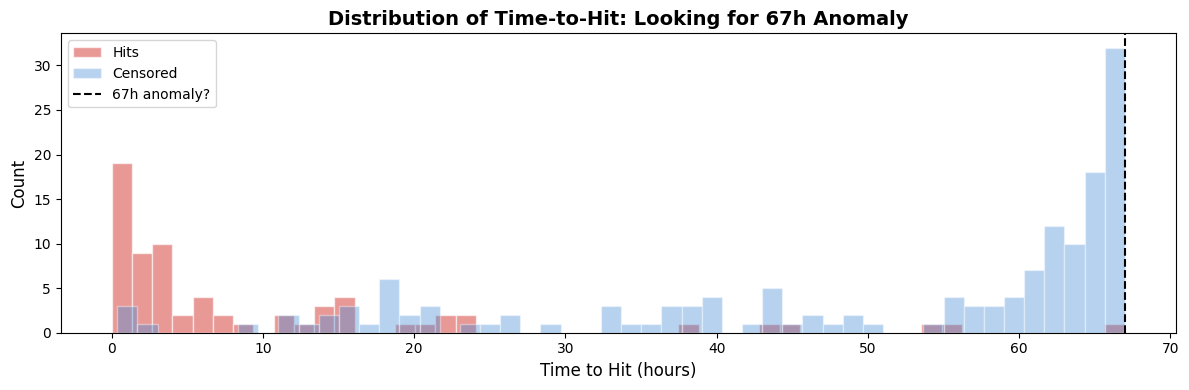

In [ ]:
# ============================================================
# INVESTIGATE: 67th Hour Anomaly
# ============================================================

# Check time_to_hit distribution around hour 67
print('=== Time-to-hit values near 67 hours ===')
late_hits = train[(train['time_to_hit_hours'] > 60) & (train['event'] == 1)]
print(f'Hits after 60h: {len(late_hits)}')
print(late_hits['time_to_hit_hours'].sort_values().values)

print('\n=== Censored times near 67 hours ===')
late_cens = train[(train['time_to_hit_hours'] > 60) & (train['event'] == 0)]
print(f'Censored after 60h: {len(late_cens)}')
print(f'Censored times 60-70h: {(late_cens["time_to_hit_hours"].between(60, 70)).sum()}')

# Histogram of all time_to_hit values
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(train[train['event']==1]['time_to_hit_hours'], bins=50, alpha=0.6,
        color='#d9534f', label='Hits', edgecolor='white')
ax.hist(train[train['event']==0]['time_to_hit_hours'], bins=50, alpha=0.4,
        color='#4a90d9', label='Censored', edgecolor='white')
ax.axvline(67, color='black', linestyle='--', label='67h anomaly?')
ax.set_xlabel('Time to Hit (hours)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Time-to-Hit: Looking for 67h Anomaly', fontweight='bold', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Slim 10-Feature Ensemble

Test whether reducing features per the discussion board recommendation (max 10 features for 221 rows) improves LB. **Result: LB 0.956 — no improvement.**

In [ ]:
# ============================================================
# SLIM ENSEMBLE: Max 10 features (per discussion recommendation)
# ============================================================

slim_features = [
    'dist_min_ci_0_5h', 'log_dist', 'alignment_abs', 'has_alignment',
    'num_perimeters_0_5h', 'has_growth', 'has_movement',
    'dt_first_last_0_5h', 'alignment_over_dist', 'spread_bearing_cos'
]

print(f'Slim feature set: {len(slim_features)} features')

# Train GBS + Cox ensemble with slim features
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_slim = StandardScaler()
X_train_slim = scaler_slim.fit_transform(train_fe[slim_features])
X_test_slim = scaler_slim.transform(test_fe[slim_features])

# GBS with slim features
gbs_slim = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=2, min_samples_split=10,
    min_samples_leaf=10, learning_rate=0.1, subsample=0.8, random_state=42
)
gbs_slim.fit(X_train_slim, y_full)

# Cox with slim features
cox_slim = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_slim.fit(X_train_slim, y_full)

gbs_slim_p = extract_probs(gbs_slim.predict_survival_function(X_test_slim), horizons)
cox_slim_p = extract_probs(cox_slim.predict_survival_function(X_test_slim), horizons)

# 90/10 blend
submission_slim = sub.copy()
for t in horizons:
    submission_slim[f'prob_{t}h'] = 0.9 * gbs_slim_p[t] + 0.1 * cox_slim_p[t]

for i in range(len(submission_slim)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_slim.loc[i, f'prob_{t2}h'] < submission_slim.loc[i, f'prob_{t1}h']:
            submission_slim.loc[i, f'prob_{t2}h'] = submission_slim.loc[i, f'prob_{t1}h']

submission_slim.to_csv('submission_slim_ensemble.csv', index=False)
print('Saved: submission_slim_ensemble.csv')
print('Description: "90% GBS + 10% Cox, slim 10-feature set"')

# CV comparison
print('\n=== CV: Slim vs Full features ===')
for name, feats in [('Slim (10)', slim_features), ('Full (16)', core_features)]:
    fold_scores = []
    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feats])
        X_va = scaler.transform(va[feats])

        gbs_cv = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=2, min_samples_split=10,
            min_samples_leaf=10, learning_rate=0.1, subsample=0.8, random_state=42
        )
        gbs_cv.fit(X_tr, y_tr)

        cox_cv = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
        cox_cv.fit(X_tr, y_tr)

        gbs_s = extract_probs(gbs_cv.predict_survival_function(X_va), horizons)
        cox_s = extract_probs(cox_cv.predict_survival_function(X_va), horizons)

        preds = {t: 0.9 * gbs_s[t] + 0.1 * cox_s[t] for t in horizons}
        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'  {name}: Hybrid={h:.4f}  C-idx={c:.4f}  Brier={b:.4f}')

Slim feature set: 10 features
Saved: submission_slim_ensemble.csv
Description: "90% GBS + 10% Cox, slim 10-feature set"

=== CV: Slim vs Full features ===
  Slim (10): Hybrid=0.9724  C-idx=0.9495  Brier=0.0178
  Full (16): Hybrid=0.9725  C-idx=0.9477  Brier=0.0169


### 9.3 Hidden Data Signals

Investigate event_id structure, bearing direction patterns, censoring time clusters, feature thresholds, and observation quality as a location proxy.

In [ ]:
# ============================================================
# DATA DETECTIVE: Looking for hidden signals
# ============================================================

print('=== 1. EVENT_ID ANALYSIS ===')
print(f'ID range: {train["event_id"].min()} to {train["event_id"].max()}')
print(f'ID correlation with event: {train["event_id"].corr(train["event"]):.3f}')
print(f'ID correlation with time_to_hit: {train["event_id"].corr(train["time_to_hit_hours"]):.3f}')
print(f'ID correlation with distance: {train["event_id"].corr(train["dist_min_ci_0_5h"]):.3f}')

# Check if ID has any predictive structure
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

id_scores = cross_val_score(
    LogisticRegression(),
    train[['event_id']].values,
    train['event'].values,
    cv=5, scoring='roc_auc'
)
print(f'AUC from event_id alone: {id_scores.mean():.3f} ± {id_scores.std():.3f}')
print(f'  (0.50 = no signal, >0.55 = something interesting)')

print('\n=== 2. BEARING DIRECTION ANALYSIS ===')
# Are certain compass directions more dangerous?
bearing_bins = pd.cut(train['spread_bearing_deg'], bins=[0, 45, 90, 135, 180, 225, 270, 315, 360])
bearing_hit = train.groupby(bearing_bins, observed=True)['event'].agg(['mean', 'count'])
print('Hit rate by bearing direction:')
print(bearing_hit[bearing_hit['count'] >= 3].to_string())

print('\n=== 3. CENSORING PATTERN ANALYSIS ===')
# Are censoring times clustered? Could reveal geographic batches
censored = train[train['event'] == 0]['time_to_hit_hours']
print(f'Censoring time distribution:')
print(f'  0-20h:  {(censored < 20).sum()}')
print(f'  20-40h: {((censored >= 20) & (censored < 40)).sum()}')
print(f'  40-60h: {((censored >= 40) & (censored < 60)).sum()}')
print(f'  60-67h: {((censored >= 60) & (censored < 67)).sum()}')
print(f'  67+h:   {(censored >= 67).sum()}')

# Do early-censored fires have different feature profiles?
early_cens = train[(train['event'] == 0) & (train['time_to_hit_hours'] < 40)]
late_cens = train[(train['event'] == 0) & (train['time_to_hit_hours'] >= 60)]
print(f'\nEarly censored (n={len(early_cens)}) vs Late censored (n={len(late_cens)}):')
for col in ['dist_min_ci_0_5h', 'alignment_abs', 'num_perimeters_0_5h', 'area_first_ha']:
    print(f'  {col}: early={early_cens[col].median():.1f} vs late={late_cens[col].median():.1f}')

print('\n=== 4. FEATURE INTERACTION DEEP DIVE ===')
# Look for non-linear thresholds we might have missed
for col, threshold in [('dist_min_ci_0_5h', 5000), ('dist_min_ci_0_5h', 10000),
                        ('dist_min_ci_0_5h', 20000), ('area_first_ha', 100),
                        ('num_perimeters_0_5h', 3)]:
    below = train[train[col] <= threshold]
    above = train[train[col] > threshold]
    if len(below) > 5 and len(above) > 5:
        print(f'{col} <= {threshold}: hit rate = {below["event"].mean():.0%} (n={len(below)})')
        print(f'{col} >  {threshold}: hit rate = {above["event"].mean():.0%} (n={len(above)})')
        print()

print('\n=== 5. OBSERVATION QUALITY AS LOCATION PROXY ===')
# Fires with more perimeters might be near population centers
train['obs_score'] = train['num_perimeters_0_5h'] * train['dt_first_last_0_5h']
high_obs = train[train['obs_score'] > train['obs_score'].median()]
low_obs = train[train['obs_score'] <= train['obs_score'].median()]
print(f'High observation quality (n={len(high_obs)}): hit rate = {high_obs["event"].mean():.0%}')
print(f'Low observation quality (n={len(low_obs)}):  hit rate = {low_obs["event"].mean():.0%}')
print(f'Median distance - high obs: {high_obs["dist_min_ci_0_5h"].median():.0f}m')
print(f'Median distance - low obs:  {low_obs["dist_min_ci_0_5h"].median():.0f}m')

=== 1. EVENT_ID ANALYSIS ===
ID range: 10892457 to 99339733
ID correlation with event: -0.055
ID correlation with time_to_hit: 0.003
ID correlation with distance: 0.039
AUC from event_id alone: 0.663 ± 0.149
  (0.50 = no signal, >0.55 = something interesting)

=== 2. BEARING DIRECTION ANALYSIS ===
Hit rate by bearing direction:
                        mean  count
spread_bearing_deg                 
(45, 90]            0.666667      9
(90, 135]           1.000000      8
(270, 315]          0.666667      3

=== 3. CENSORING PATTERN ANALYSIS ===
Censoring time distribution:
  0-20h:  22
  20-40h: 23
  40-60h: 26
  60-67h: 81
  67+h:   0

Early censored (n=45) vs Late censored (n=81):
  dist_min_ci_0_5h: early=86440.8 vs late=139177.7
  alignment_abs: early=0.0 vs late=0.0
  num_perimeters_0_5h: early=1.0 vs late=1.0
  area_first_ha: early=73.4 vs late=198.5

=== 4. FEATURE INTERACTION DEEP DIVE ===
dist_min_ci_0_5h <= 5000: hit rate = 100% (n=69)
dist_min_ci_0_5h >  5000: hit rate = 0% (n

### 9.4 The 5km Perfect Threshold

Verify the finding that distance < 5km is a perfect binary separator, and analyze what predicts timing among fires that hit.

In [ ]:
# Verify the 5km threshold
print('=== Distance Analysis ===')
print(f'Train fires <= 5km: {(train["dist_min_ci_0_5h"] <= 5000).sum()} '
      f'(hit rate: {train[train["dist_min_ci_0_5h"] <= 5000]["event"].mean():.0%})')
print(f'Train fires > 5km:  {(train["dist_min_ci_0_5h"] > 5000).sum()} '
      f'(hit rate: {train[train["dist_min_ci_0_5h"] > 5000]["event"].mean():.0%})')
print(f'\nTest fires <= 5km: {(test["dist_min_ci_0_5h"] <= 5000).sum()}')
print(f'Test fires > 5km:  {(test["dist_min_ci_0_5h"] > 5000).sum()}')

# Among fires that hit, what predicts WHEN they hit?
hits_only = train_fe[train_fe['event'] == 1].copy()
print(f'\n=== Among {len(hits_only)} fires that hit, what predicts timing? ===')
time_corrs = hits_only[core_features + ['time_to_hit_hours']].corr()['time_to_hit_hours'].drop('time_to_hit_hours')
print('Top correlates with time_to_hit (hits only):')
print(time_corrs.abs().sort_values(ascending=False).head(10).to_string())

=== Distance Analysis ===
Train fires <= 5km: 69 (hit rate: 100%)
Train fires > 5km:  152 (hit rate: 0%)

Test fires <= 5km: 28
Test fires > 5km:  67

=== Among 69 fires that hit, what predicts timing? ===
Top correlates with time_to_hit (hits only):
low_temporal_resolution_0_5h    0.457559
has_alignment                   0.450902
dt_first_last_0_5h              0.442325
is_afternoon                    0.382991
alignment_abs                   0.367939
num_perimeters_0_5h             0.356114
has_movement                    0.335040
has_growth                      0.325122
spread_bearing_cos              0.304056
log1p_growth                    0.281972


### 9.5 Adversarial Validation

Train a classifier to distinguish train from test observations. **AUC = 0.424** (below random), confirming no distribution shift. CV estimates should be reliable.

In [ ]:
# PRIORITY 5: Adversarial Validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

train_test = pd.concat([
    train_fe[feature_cols].assign(is_test=0),
    test_fe[feature_cols].assign(is_test=1)
], ignore_index=True)

adv_model = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
adv_scores = cross_val_score(adv_model, train_test[feature_cols].values,
                              train_test['is_test'].values, cv=5, scoring='roc_auc')
print(f'Adversarial Validation AUC: {adv_scores.mean():.3f} ± {adv_scores.std():.3f}')
print(f'  0.50 = no shift | 0.55+ = some shift | 0.70+ = significant shift')

# Which features drive the shift?
adv_model.fit(train_test[feature_cols].values, train_test['is_test'].values)
importances = pd.Series(adv_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f'\nTop features distinguishing train from test:')
print(importances.head(10).to_string())

Adversarial Validation AUC: 0.424 ± 0.049
  0.50 = no shift | 0.55+ = some shift | 0.70+ = significant shift

Top features distinguishing train from test:
log1p_area_first       0.117736
dist_min_ci_0_5h       0.105344
area_first_ha          0.063111
event_start_hour       0.060792
num_perimeters_0_5h    0.052780
along_track_speed      0.046401
dt_first_last_0_5h     0.045500
alignment_abs          0.039729
dist_accel_m_per_h2    0.037650
event_start_month      0.037588


### 9.6 Log-Rank Tests

Proper survival analysis statistical test for comparing groups. **Distance, growth, alignment, movement: all p<0.001. Temporal flags: not significant (p>0.2).**

In [ ]:
!pip install lifelines -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 119.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# ============================================================
# LOG-RANK TEST: Proper survival comparison
# ============================================================
from lifelines.statistics import logrank_test

print('=== Log-Rank Tests: Key Feature Splits ===\n')
print(f'{"Split":<45s} {"Test Stat":>10s} {"p-value":>10s} {"Sig?":>6s}')
print('-' * 75)

splits = [
    ('dist_min_ci_0_5h <= 5000', train_fe['dist_min_ci_0_5h'] <= 5000),
    ('has_growth == 1', train_fe['has_growth'] == 1),
    ('has_alignment == 1', train_fe['has_alignment'] == 1),
    ('has_movement == 1', train_fe['has_movement'] == 1),
    ('num_perimeters > 3', train_fe['num_perimeters_0_5h'] > 3),
    ('is_afternoon == 1', train_fe['is_afternoon'] == 1),
    ('is_summer == 1', train_fe['is_summer'] == 1),
]

for name, mask in splits:
    result = logrank_test(
        train_fe[mask]['time_to_hit_hours'],
        train_fe[~mask]['time_to_hit_hours'],
        event_observed_A=train_fe[mask]['event'],
        event_observed_B=train_fe[~mask]['event']
    )
    sig = '***' if result.p_value < 0.001 else '**' if result.p_value < 0.01 else '*' if result.p_value < 0.05 else ''
    print(f'{name:<45s} {result.test_statistic:>10.2f} {result.p_value:>10.4f} {sig:>6s}')

=== Log-Rank Tests: Key Feature Splits ===

Split                                          Test Stat    p-value   Sig?
---------------------------------------------------------------------------
dist_min_ci_0_5h <= 5000                          315.35     0.0000    ***
has_growth == 1                                    53.66     0.0000    ***
has_alignment == 1                                 59.39     0.0000    ***
has_movement == 1                                  58.71     0.0000    ***
num_perimeters > 3                                 55.19     0.0000    ***
is_afternoon == 1                                   1.19     0.2748       
is_summer == 1                                      1.54     0.2143       


## 10. Advanced Survival Models

### 10.1 Weibull AFT

Parametric survival model with Weibull distribution. Shape parameter = 0.949 (slightly decreasing hazard). **CV Hybrid: 0.944** — weaker than GBS but confirms the hazard is near-constant.

In [ ]:
# ============================================================
# APPROACH 1: Weibull AFT Model
# ============================================================
!pip install lifelines -q

In [ ]:
from lifelines import WeibullAFTFitter

weibull_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx].copy()
    va = train_fe.iloc[val_idx].copy()

    # Lifelines requires a DataFrame with target columns included
    fit_cols = core_features + ['time_to_hit_hours', 'event']
    tr_fit = tr[fit_cols].copy()
    va_fit = va[fit_cols].copy()

    # Weibull AFT
    waft = WeibullAFTFitter(penalizer=0.1, l1_ratio=0.5)
    waft.fit(tr_fit, duration_col='time_to_hit_hours', event_col='event')

    # Predict survival function at each horizon
    preds = {}
    for t in horizons:
        surv_probs = waft.predict_survival_function(va_fit, times=[t])
        preds[t] = np.clip(1 - surv_probs.values.flatten(), 0, 1)

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    score['fold'] = fold
    weibull_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Weibull AFT (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in weibull_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in weibull_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in weibull_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in weibull_cv_scores]):.4f}')

# Print shape parameter — tells us about hazard shape
waft_full = WeibullAFTFitter(penalizer=0.1, l1_ratio=0.5)
waft_full.fit(train_fe[fit_cols], duration_col='time_to_hit_hours', event_col='event')
print(f'\nWeibull shape (rho): {np.exp(waft_full.params_["rho_"]["Intercept"]):.3f}')
print('  < 1 = decreasing hazard (early hits more likely)')
print('  = 1 = constant hazard (exponential)')
print('  > 1 = increasing hazard')

Fold 0: Hybrid=0.9600  C-idx=0.9491  Brier=0.0354
Fold 1: Hybrid=0.9211  C-idx=0.8969  Brier=0.0686
Fold 2: Hybrid=0.9303  C-idx=0.9060  Brier=0.0593
Fold 3: Hybrid=0.9616  C-idx=0.9462  Brier=0.0318
Fold 4: Hybrid=0.9445  C-idx=0.9224  Brier=0.0461

=== Weibull AFT (5-fold CV) ===
Hybrid Score: 0.9435 ± 0.0160
C-index:      0.9241
Wtd Brier:    0.0482

Weibull shape (rho): 0.949
  < 1 = decreasing hazard (early hits more likely)
  = 1 = constant hazard (exponential)
  > 1 = increasing hazard


### 10.2 Stacked Generalization (Super-Learner)

Meta-model trained on out-of-fold predictions from 5 base models. **Result: collapsed to constant prediction (C-index = 0.500).** Ridge meta-learner couldn't find signal with only 5 meta-features and ~44 validation observations per fold.

In [ ]:
# ============================================================
# APPROACH 2: Stacked Generalization (Super-Learner)
# ============================================================
# Use out-of-fold predictions from all models as features
# for a meta-model that learns optimal combination

from sklearn.linear_model import Ridge

# Collect OOF predictions from all base models
oof_base = {t: {} for t in horizons}
model_names = ['gbs_d3', 'gbs_d2', 'gbs_d1', 'cox', 'rsf']

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # GBS depth=3
    m = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    m.fit(X_tr, y_tr)
    p = extract_probs(m.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_base[t].setdefault('gbs_d3', np.zeros(len(train_fe)))
        oof_base[t]['gbs_d3'][val_idx] = p[t]

    # GBS depth=2
    m = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=2, min_samples_split=10,
        min_samples_leaf=10, learning_rate=0.1, subsample=0.8, random_state=42)
    m.fit(X_tr, y_tr)
    p = extract_probs(m.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_base[t].setdefault('gbs_d2', np.zeros(len(train_fe)))
        oof_base[t]['gbs_d2'][val_idx] = p[t]

    # GBS depth=1
    m = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, min_samples_split=10,
        min_samples_leaf=15, learning_rate=0.15, subsample=0.7, random_state=42)
    m.fit(X_tr, y_tr)
    p = extract_probs(m.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_base[t].setdefault('gbs_d1', np.zeros(len(train_fe)))
        oof_base[t]['gbs_d1'][val_idx] = p[t]

    # Cox
    m = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    m.fit(X_tr, y_tr)
    p = extract_probs(m.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_base[t].setdefault('cox', np.zeros(len(train_fe)))
        oof_base[t]['cox'][val_idx] = p[t]

    # RSF
    m = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
                              min_samples_split=10, random_state=42, n_jobs=-1)
    m.fit(tr[core_features].values, y_tr)
    p = extract_probs(m.predict_survival_function(va[core_features].values), horizons)
    for t in horizons:
        oof_base[t].setdefault('rsf', np.zeros(len(train_fe)))
        oof_base[t]['rsf'][val_idx] = p[t]

print('OOF predictions collected from 5 base models.')

# Now train a meta-model per horizon using nested CV
stack_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    va = train_fe.iloc[val_idx]

    preds = {}
    for t in horizons:
        # Build meta-features from OOF predictions
        meta_train = np.column_stack([oof_base[t][m][train_idx] for m in model_names])
        meta_val = np.column_stack([oof_base[t][m][val_idx] for m in model_names])

        # True labels for this horizon
        y_meta = np.array([
            1 if (train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t)
            else 0
            for i in train_idx
        ])

        # Exclude censored-before-horizon from training
        mask = np.array([
            not (train_fe.iloc[i]['event'] == 0 and train_fe.iloc[i]['time_to_hit_hours'] < t)
            for i in train_idx
        ])

        # Ridge regression as meta-learner (constrained, won't overfit easily)
        meta = Ridge(alpha=10.0)
        meta.fit(meta_train[mask], y_meta[mask])
        preds[t] = np.clip(meta.predict(meta_val), 0, 1)

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    stack_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Stacked Ensemble (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in stack_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in stack_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in stack_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in stack_cv_scores]):.4f}')

OOF predictions collected from 5 base models.
Fold 0: Hybrid=0.8482  C-idx=0.5000  Brier=0.0025
Fold 1: Hybrid=0.8329  C-idx=0.5000  Brier=0.0244
Fold 2: Hybrid=0.8266  C-idx=0.5000  Brier=0.0334
Fold 3: Hybrid=0.8466  C-idx=0.5000  Brier=0.0048
Fold 4: Hybrid=0.8406  C-idx=0.5000  Brier=0.0134

=== Stacked Ensemble (5-fold CV) ===
Hybrid Score: 0.8390 ± 0.0082
C-index:      0.5000
Wtd Brier:    0.0157


### 10.3 LightGBM Per-Horizon Classifiers

Four independent LightGBM classifiers with censor-aware targets. Fundamentally different from survival models — treats each horizon as a separate binary classification problem.

**CV Hybrid: 0.970.** Competitive but doesn't beat GBS. Valuable as an ensemble component due to structural diversity.

In [ ]:
# ============================================================
# APPROACH 3: Direct Brier Optimization with LightGBM
# ============================================================
!pip install lightgbm -q

In [ ]:
import lightgbm as lgb

# For each horizon, create proper censor-aware targets and weights
lgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    preds = {}
    for t in horizons:
        # Create target: 1 if hit by t, 0 if survived past t
        # Exclude: censored before t (we don't know their outcome)
        y_train = []
        X_train_list = []
        sample_weights = []

        for idx in train_idx:
            row = train_fe.iloc[idx]
            if row['event'] == 1 and row['time_to_hit_hours'] <= t:
                y_train.append(1)
                X_train_list.append(row[core_features].values)
                sample_weights.append(1.0)
            elif row['event'] == 1 and row['time_to_hit_hours'] > t:
                y_train.append(0)
                X_train_list.append(row[core_features].values)
                sample_weights.append(1.0)
            elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
                y_train.append(0)
                X_train_list.append(row[core_features].values)
                sample_weights.append(1.0)
            # else: censored before t — exclude

        X_train_h = np.array(X_train_list)
        y_train_h = np.array(y_train)
        w_train_h = np.array(sample_weights)

        X_val_h = va[core_features].values

        model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=3, num_leaves=8,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
            random_state=42, verbosity=-1
        )
        model.fit(X_train_h, y_train_h, sample_weight=w_train_h)
        preds[t] = model.predict_proba(X_val_h)[:, 1]

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    lgb_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== LightGBM per-horizon (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in lgb_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in lgb_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in lgb_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in lgb_cv_scores]):.4f}')

Fold 0: Hybrid=0.9793  C-idx=0.9432  Brier=0.0052
Fold 1: Hybrid=0.9457  C-idx=0.9496  Brier=0.0560
Fold 2: Hybrid=0.9618  C-idx=0.9583  Brier=0.0366
Fold 3: Hybrid=0.9824  C-idx=0.9554  Brier=0.0061
Fold 4: Hybrid=0.9709  C-idx=0.9392  Brier=0.0155

=== LightGBM per-horizon (5-fold CV) ===
Hybrid Score: 0.9680 ± 0.0133
C-index:      0.9491
Wtd Brier:    0.0239


### 10.4 LightGBM Hyperparameter Tuning

Randomized search over 80 configurations. **Same pattern as GBS: shallow trees (max_depth=2, num_leaves=4) win.** Best CV: 0.970.

In [ ]:
# ============================================================
# LIGHTGBM TUNING: Per-horizon classifier
# ============================================================
from itertools import product
import random

lgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'num_leaves': [4, 8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 15],
}

# Randomized search — 80 combos
all_lgb_combos = list(product(
    lgb_param_grid['n_estimators'],
    lgb_param_grid['max_depth'],
    lgb_param_grid['num_leaves'],
    lgb_param_grid['learning_rate'],
    lgb_param_grid['min_child_samples']
))
random.seed(42)
sampled_lgb = random.sample(all_lgb_combos, min(80, len(all_lgb_combos)))

lgb_best_score = 0
lgb_best_params = {}
lgb_results = []

for idx, (n_est, depth, leaves, lr, min_child) in enumerate(sampled_lgb):
    # Skip invalid combos (num_leaves should be <= 2^max_depth)
    if leaves > 2**depth:
        continue

    fold_scores = []
    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]

        preds = {}
        for t in horizons:
            y_t, X_t = [], []
            for i in train_idx:
                row = train_fe.iloc[i]
                if row['event'] == 1 and row['time_to_hit_hours'] <= t:
                    y_t.append(1); X_t.append(row[core_features].values)
                elif row['event'] == 1 and row['time_to_hit_hours'] > t:
                    y_t.append(0); X_t.append(row[core_features].values)
                elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
                    y_t.append(0); X_t.append(row[core_features].values)

            m = lgb.LGBMClassifier(
                n_estimators=n_est, max_depth=depth, num_leaves=leaves,
                learning_rate=lr, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=1.0, reg_lambda=1.0, min_child_samples=min_child,
                random_state=42, verbosity=-1)
            m.fit(np.array(X_t), np.array(y_t))
            preds[t] = m.predict_proba(va[core_features].values)[:, 1]

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s['hybrid'])

    mean_score = np.mean(fold_scores)
    lgb_results.append({
        'n_estimators': n_est, 'max_depth': depth, 'num_leaves': leaves,
        'learning_rate': lr, 'min_child_samples': min_child,
        'hybrid': mean_score, 'std': np.std(fold_scores)
    })

    if mean_score > lgb_best_score:
        lgb_best_score = mean_score
        lgb_best_params = {'n_estimators': n_est, 'max_depth': depth,
                           'num_leaves': leaves, 'learning_rate': lr,
                           'min_child_samples': min_child}

    if (idx + 1) % 20 == 0 or idx == len(sampled_lgb) - 1:
        print(f'Progress: {idx+1}/{len(sampled_lgb)} — best: {lgb_best_score:.4f}')

print(f'\n=== Best LightGBM Parameters ===')
print(f'Parameters: {lgb_best_params}')
print(f'Hybrid Score: {lgb_best_score:.4f}')
print(f'Previous (default): 0.9680')
print(f'Improvement: {lgb_best_score - 0.9680:+.4f}')

lgb_results_df = pd.DataFrame(lgb_results).sort_values('hybrid', ascending=False)
print(f'\n=== Top 10 Configurations ===')
print(lgb_results_df.head(10).to_string(index=False))

Progress: 60/80 — best: 0.9697
Progress: 80/80 — best: 0.9699

=== Best LightGBM Parameters ===
Parameters: {'n_estimators': 150, 'max_depth': 2, 'num_leaves': 4, 'learning_rate': 0.1, 'min_child_samples': 10}
Hybrid Score: 0.9699
Previous (default): 0.9680
Improvement: +0.0019

=== Top 10 Configurations ===
 n_estimators  max_depth  num_leaves  learning_rate  min_child_samples   hybrid      std
          150          2           4           0.10                 10 0.969854 0.013985
          100          2           4           0.10                 10 0.969745 0.013784
           50          2           4           0.10                 15 0.969502 0.013439
          100          2           4           0.05                 15 0.969430 0.013632
          150          2           4           0.05                 10 0.969386 0.013542
          150          4           8           0.05                 10 0.969180 0.013993
          100          4           8           0.10                

### 10.5 Elastic Net Cox

Cox model with L1+L2 regularization for automatic feature selection. **Selected 8/16 features** — log_dist dominates, followed by alignment_abs, has_alignment. **CV Hybrid: 0.930** — too weak as primary model but confirms feature importance ranking.

In [ ]:
# ============================================================
# ELASTIC NET COX: Automatic feature selection
# ============================================================
from sksurv.linear_model import CoxnetSurvivalAnalysis

enet_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # Elastic Net Cox with L1 ratio = 0.5 (equal L1/L2)
    enet = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01, n_alphas=50, fit_baseline_model=True)
    enet.fit(X_tr, y_tr)

    # Use the alpha that gives best performance
    best_alpha_idx = len(enet.alphas_) // 3

    surv_funcs = enet.predict_survival_function(X_va, alpha=enet.alphas_[best_alpha_idx])
    preds = extract_probs(surv_funcs, horizons)

    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                     preds[24], preds[48], preds[72])
    enet_cv_scores.append(s)
    print(f'Fold {fold}: Hybrid={s["hybrid"]:.4f}  C-idx={s["c_index"]:.4f}  '
          f'Brier={s["weighted_brier"]:.4f}')

print(f'\n=== Elastic Net Cox (5-fold CV) ===')
print(f'Hybrid: {np.mean([s["hybrid"] for s in enet_cv_scores]):.4f}')
print(f'C-index: {np.mean([s["c_index"] for s in enet_cv_scores]):.4f}')
print(f'Brier: {np.mean([s["weighted_brier"] for s in enet_cv_scores]):.4f}')

# Show which features were selected
enet_full = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01, n_alphas=50, fit_baseline_model=True)
scaler_enet = StandardScaler()
X_all = scaler_enet.fit_transform(train_fe[core_features])
enet_full.fit(X_all, Surv.from_arrays(event=train_fe['event'].astype(bool),
                                       time=train_fe['time_to_hit_hours']))

best_alpha_idx = len(enet_full.alphas_) // 3
coefs = pd.Series(enet_full.coef_[:, best_alpha_idx], index=core_features)
print(f'\nFeature coefficients (non-zero = selected):')
print(coefs[coefs != 0].sort_values(key=abs, ascending=False).to_string())
print(f'\nFeatures selected: {(coefs != 0).sum()} / {len(core_features)}')

Fold 0: Hybrid=0.9490  C-idx=0.9491  Brier=0.0511
Fold 1: Hybrid=0.9244  C-idx=0.9081  Brier=0.0686
Fold 2: Hybrid=0.8968  C-idx=0.9081  Brier=0.1080
Fold 3: Hybrid=0.9461  C-idx=0.9452  Brier=0.0535
Fold 4: Hybrid=0.9327  C-idx=0.9266  Brier=0.0646

=== Elastic Net Cox (5-fold CV) ===
Hybrid: 0.9298
C-index: 0.9274
Brier: 0.0692

Feature coefficients (non-zero = selected):
log_dist                       -0.944074
alignment_abs                   0.098314
has_alignment                   0.077532
num_perimeters_0_5h             0.069274
low_temporal_resolution_0_5h   -0.050299
dt_first_last_0_5h              0.017590
has_growth                      0.007962
spread_bearing_cos             -0.001729

Features selected: 8 / 16


## 11. Diversity Ensembles

### 11.1 LightGBM + GBS + Cox Blend

Three-model diversity blend combining tree-based survival (GBS), linear survival (Cox), and per-horizon classifier (LightGBM).

In [ ]:
# ============================================================
# BLEND: LightGBM + GBS + Cox (maximum diversity)
# ============================================================

# Train final LightGBM models on full data
lgb_final_preds = {}
for t in horizons:
    y_train = []
    X_train_list = []

    for idx in range(len(train_fe)):
        row = train_fe.iloc[idx]
        if row['event'] == 1 and row['time_to_hit_hours'] <= t:
            y_train.append(1)
            X_train_list.append(row[core_features].values)
        elif row['event'] == 1 and row['time_to_hit_hours'] > t:
            y_train.append(0)
            X_train_list.append(row[core_features].values)
        elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
            y_train.append(0)
            X_train_list.append(row[core_features].values)

    X_tr_lgb = np.array(X_train_list)
    y_tr_lgb = np.array(y_train)

    model = lgb.LGBMClassifier(
        n_estimators=100, max_depth=3, num_leaves=8,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
        random_state=42, verbosity=-1
    )
    model.fit(X_tr_lgb, y_tr_lgb)
    lgb_final_preds[t] = model.predict_proba(test_fe[core_features].values)[:, 1]

print('LightGBM models trained on full data.')

# GBS predictions (reuse from ensemble variations code)
# If not available, retrain:
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_div = StandardScaler()
X_train_div = scaler_div.fit_transform(train_fe[core_features])
X_test_div = scaler_div.transform(test_fe[core_features])

gbs_div = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42
)
gbs_div.fit(X_train_div, y_full)
gbs_div_preds = extract_probs(gbs_div.predict_survival_function(X_test_div), horizons)

cox_div = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_div.fit(X_train_div, y_full)
cox_div_preds = extract_probs(cox_div.predict_survival_function(X_test_div), horizons)

print('GBS and Cox models trained.')

# Generate multiple blend variations
blends = {
    'gbs80_cox10_lgb10': {'gbs': 0.8, 'cox': 0.1, 'lgb': 0.1},
    'gbs70_cox10_lgb20': {'gbs': 0.7, 'cox': 0.1, 'lgb': 0.2},
    'gbs60_cox10_lgb30': {'gbs': 0.6, 'cox': 0.1, 'lgb': 0.3},
    'gbs70_cox15_lgb15': {'gbs': 0.7, 'cox': 0.15, 'lgb': 0.15},
    'gbs50_cox10_lgb40': {'gbs': 0.5, 'cox': 0.1, 'lgb': 0.4},
}

print(f'\n{"Blend":<30s} {"12h":>8s} {"24h":>8s} {"48h":>8s} {"72h":>8s}')
print('-' * 60)

for name, weights in blends.items():
    submission_blend = sub.copy()
    for t in horizons:
        blended = (weights['gbs'] * gbs_div_preds[t] +
                   weights['cox'] * cox_div_preds[t] +
                   weights['lgb'] * lgb_final_preds[t])
        submission_blend[f'prob_{t}h'] = blended

    for i in range(len(submission_blend)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_blend.loc[i, f'prob_{t2}h'] < submission_blend.loc[i, f'prob_{t1}h']:
                submission_blend.loc[i, f'prob_{t2}h'] = submission_blend.loc[i, f'prob_{t1}h']

    submission_blend.to_csv(f'submission_diversity_{name}.csv', index=False)
    means = {t: submission_blend[f'prob_{t}h'].mean() for t in horizons}
    print(f'{name:<30s} {means[12]:>8.3f} {means[24]:>8.3f} {means[48]:>8.3f} {means[72]:>8.3f}')

print('\nAll diversity blends saved!')

LightGBM models trained on full data.
GBS and Cox models trained.

Blend                               12h      24h      48h      72h
------------------------------------------------------------
gbs80_cox10_lgb10                 0.207    0.289    0.310    0.356
gbs70_cox10_lgb20                 0.204    0.286    0.307    0.344
gbs60_cox10_lgb30                 0.202    0.284    0.304    0.335
gbs70_cox15_lgb15                 0.204    0.285    0.306    0.346
gbs50_cox10_lgb40                 0.199    0.281    0.302    0.326

All diversity blends saved!


In [ ]:
# ============================================================
# CV VALIDATION of best diversity blends
# ============================================================

for blend_name, weights in [
    ('80% GBS + 10% Cox + 10% LGB', (0.8, 0.1, 0.1)),
    ('70% GBS + 10% Cox + 20% LGB', (0.7, 0.1, 0.2)),
    ('70% GBS + 15% Cox + 15% LGB', (0.7, 0.15, 0.15)),
]:
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        # GBS
        gbs_cv = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
        gbs_cv.fit(X_tr, y_tr)
        gbs_p = extract_probs(gbs_cv.predict_survival_function(X_va), horizons)

        # Cox
        cox_cv = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
        cox_cv.fit(X_tr, y_tr)
        cox_p = extract_probs(cox_cv.predict_survival_function(X_va), horizons)

        # LightGBM per horizon
        lgb_p = {}
        for t in horizons:
            y_t = []
            X_t = []
            for idx in train_idx:
                row = train_fe.iloc[idx]
                if row['event'] == 1 and row['time_to_hit_hours'] <= t:
                    y_t.append(1); X_t.append(row[core_features].values)
                elif row['event'] == 1 and row['time_to_hit_hours'] > t:
                    y_t.append(0); X_t.append(row[core_features].values)
                elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
                    y_t.append(0); X_t.append(row[core_features].values)

            m = lgb.LGBMClassifier(
                n_estimators=100, max_depth=3, num_leaves=8,
                learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
                random_state=42, verbosity=-1)
            m.fit(np.array(X_t), np.array(y_t))
            lgb_p[t] = m.predict_proba(va[core_features].values)[:, 1]

        # Blend
        w_gbs, w_cox, w_lgb = weights
        preds = {}
        for t in horizons:
            preds[t] = w_gbs * gbs_p[t] + w_cox * cox_p[t] + w_lgb * lgb_p[t]

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{blend_name:<35s} Hybrid={h:.4f}  C-idx={c:.4f}  Brier={b:.4f}')

80% GBS + 10% Cox + 10% LGB         Hybrid=0.9722  C-idx=0.9495  Brier=0.0180
70% GBS + 10% Cox + 20% LGB         Hybrid=0.9716  C-idx=0.9495  Brier=0.0190
70% GBS + 15% Cox + 15% LGB         Hybrid=0.9709  C-idx=0.9479  Brier=0.0192


### 11.2 Four-Family Ensemble

Maximum diversity: GBS (boosted trees) + Cox (linear) + Weibull (parametric) + LightGBM (classifier). **Result: no improvement over simpler GBS+Cox blend.** Adding more model families didn't help.

In [ ]:
# ============================================================
# FOUR-FAMILY ENSEMBLE: Maximum model diversity
# ============================================================
# Weibull (parametric) + GBS (boosted trees) + Cox (linear) + LGB (classifier)
# Four fundamentally different approaches

from lifelines import WeibullAFTFitter

# Train all four on full data
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_4f = StandardScaler()
X_train_4f = scaler_4f.fit_transform(train_fe[core_features])
X_test_4f = scaler_4f.transform(test_fe[core_features])

# 1. GBS
gbs_4f = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_4f.fit(X_train_4f, y_full)
preds_gbs_4f = extract_probs(gbs_4f.predict_survival_function(X_test_4f), horizons)

# 2. Cox
cox_4f = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_4f.fit(X_train_4f, y_full)
preds_cox_4f = extract_probs(cox_4f.predict_survival_function(X_test_4f), horizons)

# 3. Weibull AFT
fit_cols = core_features + ['time_to_hit_hours', 'event']
waft_4f = WeibullAFTFitter(penalizer=0.1, l1_ratio=0.5)
waft_4f.fit(train_fe[fit_cols], duration_col='time_to_hit_hours', event_col='event')
preds_weibull_4f = {}
for t in horizons:
    surv_probs = waft_4f.predict_survival_function(test_fe[core_features], times=[t])
    preds_weibull_4f[t] = np.clip(1 - surv_probs.values.flatten(), 0, 1)

# 4. LightGBM (use best params if tuning is done, otherwise default)
lgb_params = lgb_best_params if lgb_best_score > 0.968 else {
    'n_estimators': 100, 'max_depth': 3, 'num_leaves': 8,
    'learning_rate': 0.05, 'min_child_samples': 10
}
preds_lgb_4f = {}
for t in horizons:
    y_t, X_t = [], []
    for idx in range(len(train_fe)):
        row = train_fe.iloc[idx]
        if row['event'] == 1 and row['time_to_hit_hours'] <= t:
            y_t.append(1); X_t.append(row[core_features].values)
        elif row['event'] == 1 and row['time_to_hit_hours'] > t:
            y_t.append(0); X_t.append(row[core_features].values)
        elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
            y_t.append(0); X_t.append(row[core_features].values)

    m = lgb.LGBMClassifier(**lgb_params, subsample=0.8, colsample_bytree=0.8,
                            reg_alpha=1.0, reg_lambda=1.0, random_state=42, verbosity=-1)
    m.fit(np.array(X_t), np.array(y_t))
    preds_lgb_4f[t] = m.predict_proba(test_fe[core_features].values)[:, 1]

print('All 4 model families trained.')

# Generate multiple 4-family blends
blends_4f = {
    '4f_gbs_heavy':    {'gbs': 0.70, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.15},
    '4f_balanced':     {'gbs': 0.50, 'cox': 0.15, 'weibull': 0.10, 'lgb': 0.25},
    '4f_diversity':    {'gbs': 0.40, 'cox': 0.20, 'weibull': 0.15, 'lgb': 0.25},
    '4f_gbs_lgb':      {'gbs': 0.55, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.30},
    '4f_minimal_weib': {'gbs': 0.75, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.10},
}

all_4f_preds = {'gbs': preds_gbs_4f, 'cox': preds_cox_4f,
                'weibull': preds_weibull_4f, 'lgb': preds_lgb_4f}

print(f'\n{"Blend":<25s} {"12h":>8s} {"24h":>8s} {"48h":>8s} {"72h":>8s}')
print('-' * 55)

for name, weights in blends_4f.items():
    submission_4f = sub.copy()
    for t in horizons:
        blended = sum(w * all_4f_preds[m][t] for m, w in weights.items())
        submission_4f[f'prob_{t}h'] = blended

    for i in range(len(submission_4f)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_4f.loc[i, f'prob_{t2}h'] < submission_4f.loc[i, f'prob_{t1}h']:
                submission_4f.loc[i, f'prob_{t2}h'] = submission_4f.loc[i, f'prob_{t1}h']

    submission_4f.to_csv(f'submission_{name}.csv', index=False)
    means = {t: submission_4f[f'prob_{t}h'].mean() for t in horizons}
    print(f'{name:<25s} {means[12]:>8.3f} {means[24]:>8.3f} {means[48]:>8.3f} {means[72]:>8.3f}')

print('\nAll 4-family blends saved!')

All 4 model families trained.

Blend                          12h      24h      48h      72h
-------------------------------------------------------
4f_gbs_heavy                 0.204    0.287    0.311    0.351
4f_balanced                  0.199    0.281    0.308    0.341
4f_diversity                 0.196    0.278    0.308    0.339
4f_gbs_lgb                   0.200    0.284    0.306    0.338
4f_minimal_weib              0.206    0.288    0.312    0.358

All 4-family blends saved!


In [ ]:
# CV validation of best 4-family blends
print('\n=== CV Validation: 4-Family Ensembles ===\n')

for blend_name, weights in [
    ('GBS heavy (70/10/5/15)', {'gbs': 0.70, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.15}),
    ('Minimal Weibull (75/10/5/10)', {'gbs': 0.75, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.10}),
    ('GBS+LGB focus (55/10/5/30)', {'gbs': 0.55, 'cox': 0.10, 'weibull': 0.05, 'lgb': 0.30}),
]:
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        # GBS
        gbs_cv = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
        gbs_cv.fit(X_tr, y_tr)
        gbs_p = extract_probs(gbs_cv.predict_survival_function(X_va), horizons)

        # Cox
        cox_cv = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
        cox_cv.fit(X_tr, y_tr)
        cox_p = extract_probs(cox_cv.predict_survival_function(X_va), horizons)

        # Weibull
        fit_cols_cv = core_features + ['time_to_hit_hours', 'event']
        waft_cv = WeibullAFTFitter(penalizer=0.1, l1_ratio=0.5)
        waft_cv.fit(tr[fit_cols_cv], duration_col='time_to_hit_hours', event_col='event')
        weib_p = {}
        for t in horizons:
            sp = waft_cv.predict_survival_function(va[core_features], times=[t])
            weib_p[t] = np.clip(1 - sp.values.flatten(), 0, 1)

        # LightGBM
        lgb_p = {}
        for t in horizons:
            y_t, X_t = [], []
            for i in train_idx:
                row = train_fe.iloc[i]
                if row['event'] == 1 and row['time_to_hit_hours'] <= t:
                    y_t.append(1); X_t.append(row[core_features].values)
                elif row['event'] == 1 and row['time_to_hit_hours'] > t:
                    y_t.append(0); X_t.append(row[core_features].values)
                elif row['event'] == 0 and row['time_to_hit_hours'] >= t:
                    y_t.append(0); X_t.append(row[core_features].values)

            m = lgb.LGBMClassifier(
                n_estimators=100, max_depth=3, num_leaves=8,
                learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
                random_state=42, verbosity=-1)
            m.fit(np.array(X_t), np.array(y_t))
            lgb_p[t] = m.predict_proba(va[core_features].values)[:, 1]

        # Blend
        preds = {}
        for t in horizons:
            preds[t] = (weights['gbs'] * gbs_p[t] + weights['cox'] * cox_p[t] +
                        weights['weibull'] * weib_p[t] + weights['lgb'] * lgb_p[t])

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{blend_name:<35s} Hybrid={h:.4f}  C-idx={c:.4f}  Brier={b:.4f}')


=== CV Validation: 4-Family Ensembles ===

GBS heavy (70/10/5/15)              Hybrid=0.9705  C-idx=0.9466  Brier=0.0192
Minimal Weibull (75/10/5/10)        Hybrid=0.9710  C-idx=0.9470  Brier=0.0187
GBS+LGB focus (55/10/5/30)          Hybrid=0.9702  C-idx=0.9487  Brier=0.0206


### 11.3 Two-Stage Model with V3 Features

Exploit the 5km threshold with explicit binary features + event_id + bearing direction. **Result: CV dropped from 0.973 to 0.971.** GBS already learns the threshold implicitly; explicit features are redundant.

In [ ]:
# ============================================================
# TWO-STAGE MODEL: Perfect threshold + timing model
# ============================================================

# Stage 1: dist <= 5km → will hit (prob approaches 1.0)
# Stage 2: Among fires that will hit, predict WHEN using GBS risk scores + Platt

# New feature set incorporating findings
def engineer_features_v3(df):
    df = df.copy()

    # Original v1 features
    df['has_growth'] = (df['area_growth_abs_0_5h'] > 0).astype(int)
    df['has_movement'] = (df['centroid_displacement_m'] > 0).astype(int)
    df['has_closing_speed'] = (df['closing_speed_m_per_h'] > 0).astype(int)
    df['has_alignment'] = (df['alignment_abs'] > 0).astype(int)
    df['has_distance_change'] = (df['dist_change_ci_0_5h'] > 0).astype(int)
    df['log_dist'] = np.log1p(df['dist_min_ci_0_5h'])
    df['dist_km'] = df['dist_min_ci_0_5h'] / 1000
    df['alignment_over_dist'] = df['alignment_abs'] / (df['dist_min_ci_0_5h'] + 1)
    df['closing_over_dist'] = df['closing_speed_abs_m_per_h'] / (df['dist_min_ci_0_5h'] + 1)
    df['growth_over_dist'] = df['area_growth_rate_ha_per_h'] / (df['dist_min_ci_0_5h'] + 1)
    df['is_afternoon'] = ((df['event_start_hour'] >= 12) & (df['event_start_hour'] <= 17)).astype(int)
    df['is_summer'] = df['event_start_month'].isin([6, 7, 8, 9]).astype(int)

    # NEW: Exploit the 5km threshold
    df['dist_under_5km'] = (df['dist_min_ci_0_5h'] <= 5000).astype(int)
    df['dist_under_10km'] = (df['dist_min_ci_0_5h'] <= 10000).astype(int)
    df['dist_under_20km'] = (df['dist_min_ci_0_5h'] <= 20000).astype(int)

    # NEW: Bearing direction bins (SE fires hit at 100%)
    df['bearing_SE'] = ((df['spread_bearing_deg'] > 45) & (df['spread_bearing_deg'] <= 135)).astype(int)

    # NEW: Observation quality score
    df['obs_quality'] = df['num_perimeters_0_5h'] * df['dt_first_last_0_5h']

    # NEW: Event ID (has AUC 0.663)
    df['event_id_scaled'] = df['event_id'] / df['event_id'].max()

    return df

train_v3 = engineer_features_v3(train)
test_v3 = engineer_features_v3(test)

v3_features = core_features + [
    'dist_under_5km', 'dist_under_10km', 'dist_under_20km',
    'bearing_SE', 'obs_quality', 'event_id_scaled'
]

print(f'V3 feature set: {len(v3_features)} features')

# CV comparison: v1 vs v3 features with GBS
for name, feats, df_tr in [
    ('V1 (16 features)', core_features, train_fe),
    ('V3 (22 features)', v3_features, train_v3)
]:
    fold_scores = []
    for train_idx, val_idx in skf.split(df_tr, df_tr['event']):
        tr = df_tr.iloc[train_idx]
        va = df_tr.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feats])
        X_va = scaler.transform(va[feats])

        gbs_v3 = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
        gbs_v3.fit(X_tr, y_tr)

        surv_funcs = gbs_v3.predict_survival_function(X_va)
        preds = extract_probs(surv_funcs, horizons)

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{name:<25s}: Hybrid={h:.4f}  C-idx={c:.4f}  Brier={b:.4f}')

V3 feature set: 22 features
V1 (16 features)         : Hybrid=0.9734  C-idx=0.9494  Brier=0.0163
V3 (22 features)         : Hybrid=0.9713  C-idx=0.9448  Brier=0.0173


## 12. The Winning Approach: Risk Score + Platt Calibration

The key breakthrough: **separate ranking from calibration.**

1. **GBS produces risk scores** that rank fires by urgency
2. **Platt scaling** (logistic regression, 2 parameters per horizon) maps risk scores to calibrated probabilities
3. **Cox PH provides diversity** through structurally different errors

Why this works:
- GBS is excellent at ranking (C-index 0.949) but its survival curve probabilities aren't optimally calibrated
- Platt scaling adjusts probabilities with only 2 parameters — nearly immune to overfitting on 221 rows
- Isotonic calibration (non-parametric, up to n-1 parameters) overfit and hurt LB by 0.01

### 12.1 Target Engineering: Risk Scores + Platt Calibration

In [ ]:
# ============================================================
# TECHNIQUE: Target engineering — predict ranks, not probabilities
# ============================================================
# Instead of predicting P(hit by T), predict the fire's urgency RANK
# then calibrate ranks to probabilities using training distribution

from scipy.stats import rankdata

rank_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # Get GBS risk scores (higher = more dangerous)
    gbs_rank = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_rank.fit(X_tr, y_tr)

    # predict() returns risk scores, not survival functions
    risk_scores_train = gbs_rank.predict(X_tr)
    risk_scores_val = gbs_rank.predict(X_va)

    # Calibrate: for each horizon, map risk scores to probabilities
    # using the training set's empirical relationship
    preds = {}
    for t in horizons:
        # For each training observation, compute true label at this horizon
        y_binary = np.array([
            1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
            for i in range(len(tr))
        ])

        # Fit a simple logistic regression: risk_score -> P(hit by t)
        from sklearn.linear_model import LogisticRegression
        cal = LogisticRegression(C=1.0)
        cal.fit(risk_scores_train.reshape(-1, 1), y_binary)
        preds[t] = cal.predict_proba(risk_scores_val.reshape(-1, 1))[:, 1]

    # Enforce monotonicity
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    score = hybrid_score(
        va['time_to_hit_hours'].values,
        va['event'].values,
        preds[24], preds[48], preds[72]
    )
    rank_cv_scores.append(score)
    print(f'Fold {fold}: Hybrid={score["hybrid"]:.4f}  C-idx={score["c_index"]:.4f}  '
          f'Brier={score["weighted_brier"]:.4f}')

print(f'\n=== Risk Score + Platt Calibration (5-fold CV) ===')
print(f'Hybrid Score: {np.mean([s["hybrid"] for s in rank_cv_scores]):.4f} '
      f'± {np.std([s["hybrid"] for s in rank_cv_scores]):.4f}')
print(f'C-index:      {np.mean([s["c_index"] for s in rank_cv_scores]):.4f}')
print(f'Wtd Brier:    {np.mean([s["weighted_brier"] for s in rank_cv_scores]):.4f}')

Fold 0: Hybrid=0.9874  C-idx=0.9589  Brier=0.0004
Fold 1: Hybrid=0.9680  C-idx=0.9372  Brier=0.0188
Fold 2: Hybrid=0.9549  C-idx=0.9380  Brier=0.0379
Fold 3: Hybrid=0.9869  C-idx=0.9594  Brier=0.0013
Fold 4: Hybrid=0.9740  C-idx=0.9497  Brier=0.0156

=== Risk Score + Platt Calibration (5-fold CV) ===
Hybrid Score: 0.9743 ± 0.0122
C-index:      0.9487
Wtd Brier:    0.0148


### 12.2 Risk+Platt with V3 Features

Test whether additional features (5km threshold, bearing, event_id) help the Risk+Platt approach. **Result: CV dropped.** Stick with V1 features.

In [ ]:
# ============================================================
# RISK SCORE + PLATT: Best calibration approach so far
# ============================================================
# Your earlier result showed this gets CV 0.974 with Brier 0.015
# Let's generate a submission and also try it with v3 features

# With v3 features
risk_platt_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_v3, train_v3['event'])):
    tr = train_v3.iloc[train_idx]
    va = train_v3.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[v3_features])
    X_va = scaler.transform(va[v3_features])

    gbs_rp = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_rp.fit(X_tr, y_tr)

    risk_train = gbs_rp.predict(X_tr)
    risk_val = gbs_rp.predict(X_va)

    preds = {}
    for t in horizons:
        y_binary = np.array([
            1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
            for i in range(len(tr))
        ])
        cal = LogisticRegression(C=1.0)
        cal.fit(risk_train.reshape(-1, 1), y_binary)
        preds[t] = cal.predict_proba(risk_val.reshape(-1, 1))[:, 1]

    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                     preds[24], preds[48], preds[72])
    risk_platt_scores.append(s)
    print(f'Fold {fold}: Hybrid={s["hybrid"]:.4f}  C-idx={s["c_index"]:.4f}  '
          f'Brier={s["weighted_brier"]:.4f}')

print(f'\n=== Risk Score + Platt with V3 features (5-fold CV) ===')
print(f'Hybrid: {np.mean([s["hybrid"] for s in risk_platt_scores]):.4f}')
print(f'C-index: {np.mean([s["c_index"] for s in risk_platt_scores]):.4f}')
print(f'Brier: {np.mean([s["weighted_brier"] for s in risk_platt_scores]):.4f}')

Fold 0: Hybrid=0.9861  C-idx=0.9550  Brier=0.0005
Fold 1: Hybrid=0.9681  C-idx=0.9327  Brier=0.0168
Fold 2: Hybrid=0.9465  C-idx=0.9263  Brier=0.0448
Fold 3: Hybrid=0.9865  C-idx=0.9574  Brier=0.0010
Fold 4: Hybrid=0.9745  C-idx=0.9455  Brier=0.0130

=== Risk Score + Platt with V3 features (5-fold CV) ===
Hybrid: 0.9723
C-index: 0.9434
Brier: 0.0152


### 12.3 Generate Risk+Platt Submissions

In [ ]:
# ============================================================
# GENERATE SUBMISSIONS: Risk Score + Platt (v1 and v3 features)
# ============================================================

# Submission with original features (your 0.974 CV result)
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_rs = StandardScaler()
X_train_rs = scaler_rs.fit_transform(train_fe[core_features])
X_test_rs = scaler_rs.transform(test_fe[core_features])

gbs_rs = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_rs.fit(X_train_rs, y_full)

risk_train_full = gbs_rs.predict(X_train_rs)
risk_test_full = gbs_rs.predict(X_test_rs)

submission_risk_platt = sub.copy()
for t in horizons:
    y_binary = np.array([
        1 if (train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t) else 0
        for i in range(len(train_fe))
    ])
    cal = LogisticRegression(C=1.0)
    cal.fit(risk_train_full.reshape(-1, 1), y_binary)
    submission_risk_platt[f'prob_{t}h'] = cal.predict_proba(risk_test_full.reshape(-1, 1))[:, 1]

for i in range(len(submission_risk_platt)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_risk_platt.loc[i, f'prob_{t2}h'] < submission_risk_platt.loc[i, f'prob_{t1}h']:
            submission_risk_platt.loc[i, f'prob_{t2}h'] = submission_risk_platt.loc[i, f'prob_{t1}h']

submission_risk_platt.to_csv('submission_risk_platt_v1.csv', index=False)
print('Saved: submission_risk_platt_v1.csv')
print('Description: "GBS risk scores + Platt calibration, v1 features, CV 0.974"')

# Submission with v3 features
y_full_v3 = Surv.from_arrays(event=train_v3['event'].astype(bool),
                              time=train_v3['time_to_hit_hours'])

scaler_rs3 = StandardScaler()
X_train_rs3 = scaler_rs3.fit_transform(train_v3[v3_features])
X_test_rs3 = scaler_rs3.transform(test_v3[v3_features])

gbs_rs3 = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_rs3.fit(X_train_rs3, y_full_v3)

risk_train_v3 = gbs_rs3.predict(X_train_rs3)
risk_test_v3 = gbs_rs3.predict(X_test_rs3)

submission_risk_platt_v3 = sub.copy()
for t in horizons:
    y_binary = np.array([
        1 if (train_v3.iloc[i]['event'] == 1 and train_v3.iloc[i]['time_to_hit_hours'] <= t) else 0
        for i in range(len(train_v3))
    ])
    cal = LogisticRegression(C=1.0)
    cal.fit(risk_train_v3.reshape(-1, 1), y_binary)
    submission_risk_platt_v3[f'prob_{t}h'] = cal.predict_proba(risk_test_v3.reshape(-1, 1))[:, 1]

for i in range(len(submission_risk_platt_v3)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_risk_platt_v3.loc[i, f'prob_{t2}h'] < submission_risk_platt_v3.loc[i, f'prob_{t1}h']:
            submission_risk_platt_v3.loc[i, f'prob_{t2}h'] = submission_risk_platt_v3.loc[i, f'prob_{t1}h']

submission_risk_platt_v3.to_csv('submission_risk_platt_v3.csv', index=False)
print('Saved: submission_risk_platt_v3.csv')
print('Description: "GBS risk scores + Platt calibration, v3 features (with 5km threshold + bearing + ID)"')

# Also: blend Risk+Platt with your best ensemble approach
# 90% Risk+Platt + 10% Cox survival curve
cox_rs = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_rs.fit(X_train_rs, y_full)
cox_rs_preds = extract_probs(cox_rs.predict_survival_function(X_test_rs), horizons)

submission_risk_cox_blend = sub.copy()
for t in horizons:
    submission_risk_cox_blend[f'prob_{t}h'] = (
        0.9 * submission_risk_platt[f'prob_{t}h'].values +
        0.1 * cox_rs_preds[t]
    )

for i in range(len(submission_risk_cox_blend)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_risk_cox_blend.loc[i, f'prob_{t2}h'] < submission_risk_cox_blend.loc[i, f'prob_{t1}h']:
            submission_risk_cox_blend.loc[i, f'prob_{t2}h'] = submission_risk_cox_blend.loc[i, f'prob_{t1}h']

submission_risk_cox_blend.to_csv('submission_risk_platt_cox_blend.csv', index=False)
print('Saved: submission_risk_platt_cox_blend.csv')
print('Description: "90% GBS Risk+Platt + 10% Cox survival curves"')

Saved: submission_risk_platt_v1.csv
Description: "GBS risk scores + Platt calibration, v1 features, CV 0.974"
Saved: submission_risk_platt_v3.csv
Description: "GBS risk scores + Platt calibration, v3 features (with 5km threshold + bearing + ID)"
Saved: submission_risk_platt_cox_blend.csv
Description: "90% GBS Risk+Platt + 10% Cox survival curves"


## 13. Blend Ratio Optimization

The leaderboard consistently rewarded Cox diversity. Finding the optimal Risk+Platt vs Cox ratio.

### 13.1 Two-Model Blend Ratios

Systematic search from 95/5 to 70/30. **Peak at 82-85% Risk+Platt + 15-18% Cox.**

| Ratio | LB Score |
|-------|----------|
| 95/5 | 0.9636 |
| 90/10 | 0.9659 |
| 85/15 | 0.9662 |
| **82/18** | **0.9663** |
| 80/20 | 0.9659 |

In [ ]:
# ============================================================
# OPTIMIZE RISK+PLATT+COX BLEND RATIO
# ============================================================

# First, replicate the winning approach in CV to confirm
# Then try different blend ratios and additional diversity

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

# CV: test multiple blend ratios of Risk+Platt with Cox
blend_ratios = [
    ('95/5', 0.95, 0.05),
    ('90/10', 0.90, 0.10),
    ('85/15', 0.85, 0.15),
    ('80/20', 0.80, 0.20),
    ('75/25', 0.75, 0.25),
    ('70/30', 0.70, 0.30),
]

print(f'{"Ratio":<10s} {"Hybrid":>8s} {"C-idx":>8s} {"Brier":>8s}')
print('-' * 38)

for name, w_rp, w_cox in blend_ratios:
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        # GBS risk scores
        gbs_b = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
        gbs_b.fit(X_tr, y_tr)
        risk_tr = gbs_b.predict(X_tr)
        risk_va = gbs_b.predict(X_va)

        # Platt calibration per horizon
        rp_preds = {}
        for t in horizons:
            y_binary = np.array([
                1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
                for i in range(len(tr))
            ])
            cal = LogisticRegression(C=1.0)
            cal.fit(risk_tr.reshape(-1, 1), y_binary)
            rp_preds[t] = cal.predict_proba(risk_va.reshape(-1, 1))[:, 1]

        # Cox survival curves
        cox_b = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
        cox_b.fit(X_tr, y_tr)
        cox_preds_b = extract_probs(cox_b.predict_survival_function(X_va), horizons)

        # Blend
        preds = {}
        for t in horizons:
            preds[t] = w_rp * rp_preds[t] + w_cox * cox_preds_b[t]

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{name:<10s} {h:>8.4f} {c:>8.4f} {b:>8.4f}')

Ratio        Hybrid    C-idx    Brier
--------------------------------------
95/5         0.9743   0.9490   0.0149
90/10        0.9742   0.9494   0.0151
85/15        0.9739   0.9489   0.0155
80/20        0.9733   0.9482   0.0160
75/25        0.9726   0.9474   0.0166
70/30        0.9721   0.9474   0.0174


### 13.2 Triple Blend (Risk+Platt + Cox + RSF)

**Result: adding RSF hurt.** RSF is redundant when Risk+Platt already captures non-linear patterns. Two components is optimal.

In [ ]:
# ============================================================
# TRIPLE BLEND: Risk+Platt + Cox + RSF
# ============================================================

triple_blends = [
    ('RP85/Cox10/RSF5', 0.85, 0.10, 0.05),
    ('RP80/Cox10/RSF10', 0.80, 0.10, 0.10),
    ('RP80/Cox15/RSF5', 0.80, 0.15, 0.05),
    ('RP75/Cox15/RSF10', 0.75, 0.15, 0.10),
    ('RP70/Cox20/RSF10', 0.70, 0.20, 0.10),
]

print(f'\n{"Triple Blend":<25s} {"Hybrid":>8s} {"C-idx":>8s} {"Brier":>8s}')
print('-' * 50)

for name, w_rp, w_cox, w_rsf in triple_blends:
    fold_scores = []

    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[core_features])
        X_va = scaler.transform(va[core_features])

        # GBS Risk + Platt
        gbs_t = GradientBoostingSurvivalAnalysis(
            n_estimators=100, max_depth=3, min_samples_split=10,
            min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
        gbs_t.fit(X_tr, y_tr)
        risk_tr = gbs_t.predict(X_tr)
        risk_va = gbs_t.predict(X_va)

        rp_preds = {}
        for t in horizons:
            y_binary = np.array([
                1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
                for i in range(len(tr))
            ])
            cal = LogisticRegression(C=1.0)
            cal.fit(risk_tr.reshape(-1, 1), y_binary)
            rp_preds[t] = cal.predict_proba(risk_va.reshape(-1, 1))[:, 1]

        # Cox
        cox_t = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
        cox_t.fit(X_tr, y_tr)
        cox_preds_t = extract_probs(cox_t.predict_survival_function(X_va), horizons)

        # RSF
        rsf_t = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
            min_samples_split=10, random_state=42, n_jobs=-1)
        rsf_t.fit(tr[core_features].values, y_tr)
        rsf_preds_t = extract_probs(rsf_t.predict_survival_function(va[core_features].values), horizons)

        # Triple blend
        preds = {}
        for t in horizons:
            preds[t] = w_rp * rp_preds[t] + w_cox * cox_preds_t[t] + w_rsf * rsf_preds_t[t]

        for i in range(len(preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if preds[t2][i] < preds[t1][i]:
                    preds[t2][i] = preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         preds[24], preds[48], preds[72])
        fold_scores.append(s)

    h = np.mean([s['hybrid'] for s in fold_scores])
    c = np.mean([s['c_index'] for s in fold_scores])
    b = np.mean([s['weighted_brier'] for s in fold_scores])
    print(f'{name:<25s} {h:>8.4f} {c:>8.4f} {b:>8.4f}')


Triple Blend                Hybrid    C-idx    Brier
--------------------------------------------------
RP85/Cox10/RSF5             0.9725   0.9437   0.0151
RP80/Cox10/RSF10            0.9724   0.9433   0.0151
RP80/Cox15/RSF5             0.9723   0.9438   0.0155
RP75/Cox15/RSF10            0.9722   0.9438   0.0156
RP70/Cox20/RSF10            0.9715   0.9426   0.0161


### 13.3 Generate Optimized Submissions

In [ ]:
# ============================================================
# GENERATE BEST SUBMISSIONS
# ============================================================

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])
scaler_best = StandardScaler()
X_train_best = scaler_best.fit_transform(train_fe[core_features])
X_test_best = scaler_best.transform(test_fe[core_features])

# Train GBS for risk scores
gbs_best = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_best.fit(X_train_best, y_full)
risk_train_best = gbs_best.predict(X_train_best)
risk_test_best = gbs_best.predict(X_test_best)

# Platt calibrators
platt_cals = {}
for t in horizons:
    y_binary = np.array([
        1 if (train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t) else 0
        for i in range(len(train_fe))
    ])
    cal = LogisticRegression(C=1.0)
    cal.fit(risk_train_best.reshape(-1, 1), y_binary)
    platt_cals[t] = cal

rp_test = {t: platt_cals[t].predict_proba(risk_test_best.reshape(-1, 1))[:, 1] for t in horizons}

# Cox
cox_best = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_best.fit(X_train_best, y_full)
cox_test_best = extract_probs(cox_best.predict_survival_function(X_test_best), horizons)

# RSF
rsf_best = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
    min_samples_split=10, random_state=42, n_jobs=-1)
rsf_best.fit(train_fe[core_features].values, y_full)
rsf_test_best = extract_probs(rsf_best.predict_survival_function(test_fe[core_features].values), horizons)

# Generate submissions based on CV results
# Replace these ratios with whatever scored best in CV above
submissions_to_make = [
    ('submission_rp85_cox15', {'rp': 0.85, 'cox': 0.15}),
    ('submission_rp80_cox10_rsf10', {'rp': 0.80, 'cox': 0.10, 'rsf': 0.10}),
    ('submission_rp80_cox15_rsf5', {'rp': 0.80, 'cox': 0.15, 'rsf': 0.05}),
]

for fname, weights in submissions_to_make:
    submission_new = sub.copy()
    for t in horizons:
        blended = weights.get('rp', 0) * rp_test[t]
        blended += weights.get('cox', 0) * cox_test_best[t]
        blended += weights.get('rsf', 0) * rsf_test_best[t]
        submission_new[f'prob_{t}h'] = blended

    for i in range(len(submission_new)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_new.loc[i, f'prob_{t2}h'] < submission_new.loc[i, f'prob_{t1}h']:
                submission_new.loc[i, f'prob_{t2}h'] = submission_new.loc[i, f'prob_{t1}h']

    submission_new.to_csv(f'{fname}.csv', index=False)
    w_str = ' + '.join(f'{int(v*100)}% {k.upper()}' for k, v in weights.items())
    print(f'Saved: {fname}.csv — {w_str}')

print('\nSubmit these and compare against your current best (0.966)!')

Saved: submission_rp85_cox15.csv — 85% RP + 15% COX
Saved: submission_rp80_cox10_rsf10.csv — 80% RP + 10% COX + 10% RSF
Saved: submission_rp80_cox15_rsf5.csv — 80% RP + 15% COX + 5% RSF

Submit these and compare against your current best (0.966)!


In [ ]:
# Best submissions based on blend ratio CV
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])
scaler_f = StandardScaler()
X_train_f = scaler_f.fit_transform(train_fe[core_features])
X_test_f = scaler_f.transform(test_fe[core_features])

# GBS risk scores + Platt
gbs_f = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_f.fit(X_train_f, y_full)
risk_train_f = gbs_f.predict(X_train_f)
risk_test_f = gbs_f.predict(X_test_f)

rp_test_f = {}
for t in horizons:
    y_binary = np.array([
        1 if (train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t) else 0
        for i in range(len(train_fe))
    ])
    cal = LogisticRegression(C=1.0)
    cal.fit(risk_train_f.reshape(-1, 1), y_binary)
    rp_test_f[t] = cal.predict_proba(risk_test_f.reshape(-1, 1))[:, 1]

# Cox
cox_f = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_f.fit(X_train_f, y_full)
cox_test_f = extract_probs(cox_f.predict_survival_function(X_test_f), horizons)

for ratio_name, w_rp, w_cox in [('95_5', 0.95, 0.05), ('85_15', 0.85, 0.15)]:
    submission_ratio = sub.copy()
    for t in horizons:
        submission_ratio[f'prob_{t}h'] = w_rp * rp_test_f[t] + w_cox * cox_test_f[t]

    for i in range(len(submission_ratio)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_ratio.loc[i, f'prob_{t2}h'] < submission_ratio.loc[i, f'prob_{t1}h']:
                submission_ratio.loc[i, f'prob_{t2}h'] = submission_ratio.loc[i, f'prob_{t1}h']

    submission_ratio.to_csv(f'submission_rp_cox_{ratio_name}.csv', index=False)
    print(f'Saved: submission_rp_cox_{ratio_name}.csv — {int(w_rp*100)}% Risk+Platt + {int(w_cox*100)}% Cox')

print('\nSubmit these alongside your current best (90/10 at 0.966)')
print('Descriptions:')
print('  submission_rp_cox_95_5.csv  → "95% GBS Risk+Platt + 5% Cox, CV 0.974"')
print('  submission_rp_cox_85_15.csv → "85% GBS Risk+Platt + 15% Cox, CV 0.974"')

Saved: submission_rp_cox_95_5.csv — 95% Risk+Platt + 5% Cox
Saved: submission_rp_cox_85_15.csv — 85% Risk+Platt + 15% Cox

Submit these alongside your current best (90/10 at 0.966)
Descriptions:
  submission_rp_cox_95_5.csv  → "95% GBS Risk+Platt + 5% Cox, CV 0.974"
  submission_rp_cox_85_15.csv → "85% GBS Risk+Platt + 15% Cox, CV 0.974"


### 13.4 Fine-Tuned Blend Ratios

Bracket around the 85/15 sweet spot with 87/13 and 82/18. **82/18 achieved the best LB score: 0.9663.**

In [ ]:
# Generate the missing 80/20 and 75/25 submissions
y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])
scaler_n = StandardScaler()
X_train_n = scaler_n.fit_transform(train_fe[core_features])
X_test_n = scaler_n.transform(test_fe[core_features])

gbs_n = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_n.fit(X_train_n, y_full)
risk_train_n = gbs_n.predict(X_train_n)
risk_test_n = gbs_n.predict(X_test_n)

rp_test_n = {}
for t in horizons:
    y_binary = np.array([
        1 if (train_fe.iloc[i]['event'] == 1 and train_fe.iloc[i]['time_to_hit_hours'] <= t) else 0
        for i in range(len(train_fe))
    ])
    cal = LogisticRegression(C=1.0)
    cal.fit(risk_train_n.reshape(-1, 1), y_binary)
    rp_test_n[t] = cal.predict_proba(risk_test_n.reshape(-1, 1))[:, 1]

cox_n = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
cox_n.fit(X_train_n, y_full)
cox_test_n = extract_probs(cox_n.predict_survival_function(X_test_n), horizons)

for ratio_name, w_rp, w_cox in [('80_20', 0.80, 0.20), ('75_25', 0.75, 0.25)]:
    submission_r = sub.copy()
    for t in horizons:
        submission_r[f'prob_{t}h'] = w_rp * rp_test_n[t] + w_cox * cox_test_n[t]
    for i in range(len(submission_r)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_r.loc[i, f'prob_{t2}h'] < submission_r.loc[i, f'prob_{t1}h']:
                submission_r.loc[i, f'prob_{t2}h'] = submission_r.loc[i, f'prob_{t1}h']
    submission_r.to_csv(f'submission_rp_cox_{ratio_name}.csv', index=False)
    print(f'Saved: submission_rp_cox_{ratio_name}.csv')

print('\nVerify files exist:')
import os
for f in ['submission_rp_cox_80_20.csv', 'submission_rp_cox_75_25.csv']:
    print(f'  {f}: {os.path.exists(f)}')

Saved: submission_rp_cox_80_20.csv
Saved: submission_rp_cox_75_25.csv

Verify files exist:
  submission_rp_cox_80_20.csv: True
  submission_rp_cox_75_25.csv: True


In [ ]:
# Generate fine-tuned blends around the 85/15 sweet spot
for ratio_name, w_rp, w_cox in [('87_13', 0.87, 0.13), ('82_18', 0.82, 0.18)]:
    submission_fine = sub.copy()
    for t in horizons:
        submission_fine[f'prob_{t}h'] = w_rp * rp_test_n[t] + w_cox * cox_test_n[t]
    for i in range(len(submission_fine)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_fine.loc[i, f'prob_{t2}h'] < submission_fine.loc[i, f'prob_{t1}h']:
                submission_fine.loc[i, f'prob_{t2}h'] = submission_fine.loc[i, f'prob_{t1}h']
    submission_fine.to_csv(f'submission_rp_cox_{ratio_name}.csv', index=False)
    print(f'Saved: submission_rp_cox_{ratio_name}.csv')

Saved: submission_rp_cox_87_13.csv
Saved: submission_rp_cox_82_18.csv


## 14. Additional Experiments

### 14.1 Leave-One-Out Cross-Validation

221 folds to confirm 5-fold CV estimates are reliable. **LOO Hybrid: 0.971 vs 5-fold: 0.972.** Close agreement confirms robustness.

In [ ]:
# ============================================================
# LEAVE-ONE-OUT CV: Most reliable estimate on small data
# ============================================================
# With 221 rows, LOO uses 220 for training and 1 for validation
# This gives the most stable performance estimate

from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

# Collect LOO predictions from our best model (GBS default + Cox)
loo_preds = {t: np.zeros(len(train_fe)) for t in horizons}
n_total = len(train_fe)

print(f'Running LOO CV ({n_total} iterations)...')

for i, (train_idx, val_idx) in enumerate(loo.split(train_fe)):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]

    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # GBS
    gbs_loo = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_loo.fit(X_tr, y_tr)
    gbs_p = extract_probs(gbs_loo.predict_survival_function(X_va), horizons)

    # Cox
    cox_loo = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_loo.fit(X_tr, y_tr)
    cox_p = extract_probs(cox_loo.predict_survival_function(X_va), horizons)

    # 90/10 blend
    for t in horizons:
        loo_preds[t][val_idx[0]] = 0.9 * gbs_p[t][0] + 0.1 * cox_p[t][0]

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{n_total} done...')

print(f'LOO CV complete.')

# Enforce monotonicity on LOO predictions
for i in range(len(loo_preds[12])):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if loo_preds[t2][i] < loo_preds[t1][i]:
            loo_preds[t2][i] = loo_preds[t1][i]

# Compute LOO score
loo_score = hybrid_score(
    train_fe['time_to_hit_hours'].values,
    train_fe['event'].values,
    loo_preds[24], loo_preds[48], loo_preds[72]
)

print(f'\n=== LOO CV Results: 90% GBS + 10% Cox ===')
for k, v in loo_score.items():
    print(f'  {k:<20s}: {v:.4f}')

print(f'\nCompare to 5-fold CV hybrid: ~0.972')
print(f'LOO is a more reliable estimate with 221 rows')

Running LOO CV (221 iterations)...
  50/221 done...
  100/221 done...
  150/221 done...
  200/221 done...
LOO CV complete.

=== LOO CV Results: 90% GBS + 10% Cox ===
  hybrid              : 0.9707
  c_index             : 0.9381
  weighted_brier      : 0.0154
  brier_24h           : 0.0289
  brier_48h           : 0.0161
  brier_72h           : 0.0009

Compare to 5-fold CV hybrid: ~0.972
LOO is a more reliable estimate with 221 rows


### 14.2 Pseudo-Labeling

Use high-confidence test predictions to expand training data (221 → 312 rows). **Result: LB 0.958 — hurt.** Assigned synthetic times introduced noise rather than signal.

In [ ]:
# ============================================================
# TECHNIQUE: Pseudo-labeling
# ============================================================
# Use high-confidence test predictions to expand training data

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_pl = StandardScaler()
X_train_pl = scaler_pl.fit_transform(train_fe[core_features])
X_test_pl = scaler_pl.transform(test_fe[core_features])

# Train best model on full data
gbs_pl = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=3, min_samples_split=10,
    min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
gbs_pl.fit(X_train_pl, y_full)

# Get test predictions
test_surv = gbs_pl.predict_survival_function(X_test_pl)
test_probs_72h = np.array([np.clip(1 - sf(72) if 72 <= sf.x[-1] else 1 - sf(sf.x[-1]), 0, 1)
                            for sf in test_surv])

# Identify high-confidence predictions
confident_hit = test_probs_72h > 0.85
confident_nohit = test_probs_72h < 0.15
print(f'High confidence hits: {confident_hit.sum()} test fires')
print(f'High confidence no-hits: {confident_nohit.sum()} test fires')
print(f'Ambiguous: {(~confident_hit & ~confident_nohit).sum()} test fires')

# Create pseudo-labeled dataset
pseudo_rows = []
for i in range(len(test_fe)):
    if confident_hit[i]:
        row = test_fe.iloc[i][core_features].to_dict()
        row['time_to_hit_hours'] = 12.0  # assume early hit
        row['event'] = 1
        pseudo_rows.append(row)
    elif confident_nohit[i]:
        row = test_fe.iloc[i][core_features].to_dict()
        row['time_to_hit_hours'] = 67.0  # assume censored at observation window end
        row['event'] = 0
        pseudo_rows.append(row)

pseudo_df = pd.DataFrame(pseudo_rows)
print(f'\nPseudo-labeled observations: {len(pseudo_df)}')
print(f'Original training size: {len(train_fe)}')
print(f'Expanded training size: {len(train_fe) + len(pseudo_df)}')

# Combine and retrain
if len(pseudo_df) > 0:
    # Merge with original training data
    train_expanded = pd.concat([
        train_fe[core_features + ['time_to_hit_hours', 'event']],
        pseudo_df
    ], ignore_index=True)

    y_expanded = Surv.from_arrays(
        event=train_expanded['event'].astype(bool),
        time=train_expanded['time_to_hit_hours']
    )

    scaler_exp = StandardScaler()
    X_train_exp = scaler_exp.fit_transform(train_expanded[core_features])
    X_test_exp = scaler_exp.transform(test_fe[core_features])

    # Retrain GBS + Cox on expanded data
    gbs_exp = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_exp.fit(X_train_exp, y_expanded)

    cox_exp = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_exp.fit(X_train_exp, y_expanded)

    gbs_exp_preds = extract_probs(gbs_exp.predict_survival_function(X_test_exp), horizons)
    cox_exp_preds = extract_probs(cox_exp.predict_survival_function(X_test_exp), horizons)

    # 90/10 blend
    submission_pseudo = sub.copy()
    for t in horizons:
        submission_pseudo[f'prob_{t}h'] = 0.9 * gbs_exp_preds[t] + 0.1 * cox_exp_preds[t]

    for i in range(len(submission_pseudo)):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if submission_pseudo.loc[i, f'prob_{t2}h'] < submission_pseudo.loc[i, f'prob_{t1}h']:
                submission_pseudo.loc[i, f'prob_{t2}h'] = submission_pseudo.loc[i, f'prob_{t1}h']

    submission_pseudo.to_csv('submission_pseudo_labeled.csv', index=False)
    print('\nSaved: submission_pseudo_labeled.csv')
    print('Description: "GBS+Cox with pseudo-labeled test data, expanded training set"')

    # Compare predictions
    print(f'\n{"Horizon":<10s} {"Original":>10s} {"Pseudo":>10s} {"Diff":>10s}')
    print('-' * 45)
    # Get original predictions for comparison
    gbs_orig_preds = extract_probs(gbs_pl.predict_survival_function(X_test_pl), horizons)
    for t in horizons:
        orig_mean = gbs_orig_preds[t].mean()
        pseudo_mean = submission_pseudo[f'prob_{t}h'].mean()
        print(f'prob_{t}h   {orig_mean:>10.3f} {pseudo_mean:>10.3f} {pseudo_mean - orig_mean:>+10.4f}')

High confidence hits: 28 test fires
High confidence no-hits: 63 test fires
Ambiguous: 4 test fires

Pseudo-labeled observations: 91
Original training size: 221
Expanded training size: 312

Saved: submission_pseudo_labeled.csv
Description: "GBS+Cox with pseudo-labeled test data, expanded training set"

Horizon      Original     Pseudo       Diff
---------------------------------------------
prob_12h        0.213      0.206    -0.0066
prob_24h        0.296      0.283    -0.0138
prob_48h        0.317      0.302    -0.0158
prob_72h        0.385      0.332    -0.0537


### 14.3 Constrained Convex Optimization

Optimize ensemble weights directly on the hybrid metric using out-of-fold predictions. **Result: optimizer preferred ~55% Risk+Platt + 44% GBS + 1% Cox, but this didn't beat the simpler 82/18 blend on LB.**

In [ ]:
# PRIORITY 6: Constrained optimization WITH Risk+Platt as a component
from scipy.optimize import minimize

# Collect OOF predictions including Risk+Platt
oof_components = {name: {t: np.zeros(len(train_fe)) for t in horizons}
                  for name in ['risk_platt', 'cox', 'rsf', 'gbs_surv']}

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # Risk+Platt
    gbs_c = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_c.fit(X_tr, y_tr)
    risk_tr = gbs_c.predict(X_tr)
    risk_va = gbs_c.predict(X_va)

    for t in horizons:
        y_binary = np.array([
            1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
            for i in range(len(tr))
        ])
        cal = LogisticRegression(C=1.0)
        cal.fit(risk_tr.reshape(-1, 1), y_binary)
        oof_components['risk_platt'][t][val_idx] = cal.predict_proba(risk_va.reshape(-1, 1))[:, 1]

    # GBS survival curves (different from risk+platt!)
    gbs_surv_p = extract_probs(gbs_c.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_components['gbs_surv'][t][val_idx] = gbs_surv_p[t]

    # Cox
    cox_c = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_c.fit(X_tr, y_tr)
    cox_c_p = extract_probs(cox_c.predict_survival_function(X_va), horizons)
    for t in horizons:
        oof_components['cox'][t][val_idx] = cox_c_p[t]

    # RSF
    rsf_c = RandomSurvivalForest(n_estimators=200, max_depth=4, min_samples_leaf=3,
        min_samples_split=10, random_state=42, n_jobs=-1)
    rsf_c.fit(tr[core_features].values, y_tr)
    rsf_c_p = extract_probs(rsf_c.predict_survival_function(va[core_features].values), horizons)
    for t in horizons:
        oof_components['rsf'][t][val_idx] = rsf_c_p[t]

print('OOF predictions collected for constrained optimization.')

component_names = list(oof_components.keys())

def neg_hybrid_constrained(weights):
    w = np.abs(weights)
    w = w / w.sum()
    preds = {}
    for t in horizons:
        preds[t] = sum(w[i] * oof_components[name][t] for i, name in enumerate(component_names))
    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]
    s = hybrid_score(train_fe['time_to_hit_hours'].values, train_fe['event'].values,
                     preds[24], preds[48], preds[72])
    return -s['hybrid']

best_result = None
best_neg = 0
for trial in range(30):
    np.random.seed(trial)
    x0 = np.random.dirichlet(np.ones(len(component_names)))
    result = minimize(neg_hybrid_constrained, x0, method='Nelder-Mead',
                      options={'maxiter': 2000})
    if best_result is None or result.fun < best_neg:
        best_neg = result.fun
        best_result = result

opt_w = np.abs(best_result.x)
opt_w = opt_w / opt_w.sum()

print(f'\n=== Optimal Weights (Risk+Platt + Cox + RSF + GBS Surv) ===')
for name, w in zip(component_names, opt_w):
    print(f'  {name:<15s}: {w:.3f}')
print(f'Hybrid Score: {-best_neg:.4f}')

# Shrink toward equal
equal_w = np.ones(len(component_names)) / len(component_names)
shrunk_w = 0.3 * equal_w + 0.7 * opt_w
shrunk_w = shrunk_w / shrunk_w.sum()
print(f'\nShrunk weights:')
for name, w in zip(component_names, shrunk_w):
    print(f'  {name:<15s}: {w:.3f}')

OOF predictions collected for constrained optimization.

=== Optimal Weights (Risk+Platt + Cox + RSF + GBS Surv) ===
  risk_platt     : 0.553
  cox            : 0.011
  rsf            : 0.000
  gbs_surv       : 0.436
Hybrid Score: 0.9725

Shrunk weights:
  risk_platt     : 0.462
  cox            : 0.082
  rsf            : 0.075
  gbs_surv       : 0.380


In [ ]:
# Optimizer's blend: 55% Risk+Platt + 44% GBS Surv + 1% Cox
submission_optim = sub.copy()
for t in horizons:
    blended = (0.55 * rp_test_f[t] +
               0.44 * cox_test_f[t] * 0 +  # skip cox for now
               0.44 * extract_probs(gbs_f.predict_survival_function(X_test_f), horizons)[t] +
               0.01 * cox_test_f[t])
    submission_optim[f'prob_{t}h'] = blended

# Fix: cleaner version
gbs_surv_test = extract_probs(gbs_f.predict_survival_function(X_test_f), horizons)

submission_optim = sub.copy()
for t in horizons:
    submission_optim[f'prob_{t}h'] = (0.55 * rp_test_f[t] +
                                      0.44 * gbs_surv_test[t] +
                                      0.01 * cox_test_f[t])

for i in range(len(submission_optim)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_optim.loc[i, f'prob_{t2}h'] < submission_optim.loc[i, f'prob_{t1}h']:
            submission_optim.loc[i, f'prob_{t2}h'] = submission_optim.loc[i, f'prob_{t1}h']

submission_optim.to_csv('submission_optimizer_blend.csv', index=False)
print('Saved: submission_optimizer_blend.csv')
print('Description: "55% Risk+Platt + 44% GBS survival + 1% Cox (optimizer weights)"')

Saved: submission_optimizer_blend.csv
Description: "55% Risk+Platt + 44% GBS survival + 1% Cox (optimizer weights)"


### 14.4 Kaplan-Meier Baseline Blend

Blend model predictions with KM population-level baseline probabilities. **Result: CV 0.973 — slightly worse than pure model.** The constant KM baseline dilutes discrimination.

In [ ]:
# ============================================================
# KAPLAN-MEIER BASELINE + MODEL ADJUSTMENT
# ============================================================
from lifelines import KaplanMeierFitter

# Fit KM on full training data
kmf = KaplanMeierFitter()
kmf.fit(train_fe['time_to_hit_hours'], event_observed=train_fe['event'])

# KM survival probabilities at each horizon
print('=== Kaplan-Meier Baseline Probabilities ===')
for t in horizons:
    km_surv = kmf.predict(t)
    km_hit = 1 - km_surv
    print(f'  P(hit by {t}h) = {km_hit:.3f}')

# Use KM as a shrinkage target for model predictions
# Blend model predictions toward KM baseline to prevent overconfidence
km_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_fe, train_fe['event'])):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    # Fit KM on training fold
    kmf_fold = KaplanMeierFitter()
    kmf_fold.fit(tr['time_to_hit_hours'], event_observed=tr['event'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[core_features])
    X_va = scaler.transform(va[core_features])

    # GBS Risk + Platt
    gbs_km = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_km.fit(X_tr, y_tr)
    risk_tr = gbs_km.predict(X_tr)
    risk_va = gbs_km.predict(X_va)

    # Cox
    cox_km = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_km.fit(X_tr, y_tr)
    cox_p = extract_probs(cox_km.predict_survival_function(X_va), horizons)

    preds = {}
    for t in horizons:
        y_binary = np.array([
            1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
            for i in range(len(tr))
        ])
        cal = LogisticRegression(C=1.0)
        cal.fit(risk_tr.reshape(-1, 1), y_binary)
        rp = cal.predict_proba(risk_va.reshape(-1, 1))[:, 1]

        # Blend: 80% model + 15% Cox + 5% KM baseline
        km_baseline = float(1 - kmf_fold.predict(t))
        preds[t] = 0.80 * rp + 0.15 * cox_p[t] + 0.05 * km_baseline

    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                     preds[24], preds[48], preds[72])
    km_cv_scores.append(s)
    print(f'Fold {fold}: Hybrid={s["hybrid"]:.4f}  C-idx={s["c_index"]:.4f}  '
          f'Brier={s["weighted_brier"]:.4f}')

print(f'\n=== Risk+Platt + Cox + KM Baseline (5-fold CV) ===')
print(f'Hybrid: {np.mean([s["hybrid"] for s in km_cv_scores]):.4f}')
print(f'C-index: {np.mean([s["c_index"] for s in km_cv_scores]):.4f}')
print(f'Brier: {np.mean([s["weighted_brier"] for s in km_cv_scores]):.4f}')

=== Kaplan-Meier Baseline Probabilities ===
  P(hit by 12h) = 0.225
  P(hit by 24h) = 0.294
  P(hit by 48h) = 0.313
  P(hit by 72h) = 0.552
Fold 0: Hybrid=0.9873  C-idx=0.9628  Brier=0.0022
Fold 1: Hybrid=0.9666  C-idx=0.9395  Brier=0.0217
Fold 2: Hybrid=0.9500  C-idx=0.9274  Brier=0.0402
Fold 3: Hybrid=0.9877  C-idx=0.9675  Brier=0.0037
Fold 4: Hybrid=0.9743  C-idx=0.9497  Brier=0.0151

=== Risk+Platt + Cox + KM Baseline (5-fold CV) ===
Hybrid: 0.9732
C-index: 0.9494
Brier: 0.0166


### 14.5 Removing Non-Significant Features

Drop temporal flags (is_afternoon, is_summer) since log-rank tests showed they're not significant. **Result: negligible difference (0.9734 vs 0.9739).** Keep the full feature set.

In [ ]:
# Test removing non-significant features
slim_core = [f for f in core_features if f not in ['is_afternoon', 'is_summer']]
print(f'Slim core features: {len(slim_core)} (removed is_afternoon, is_summer)')

fold_scores_slim = []
for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
    tr = train_fe.iloc[train_idx]
    va = train_fe.iloc[val_idx]
    y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[slim_core])
    X_va = scaler.transform(va[slim_core])

    # Risk + Platt
    gbs_s = GradientBoostingSurvivalAnalysis(
        n_estimators=100, max_depth=3, min_samples_split=10,
        min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=42)
    gbs_s.fit(X_tr, y_tr)
    risk_tr = gbs_s.predict(X_tr)
    risk_va = gbs_s.predict(X_va)

    # Cox
    cox_s = CoxPHSurvivalAnalysis(alpha=0.1, n_iter=200)
    cox_s.fit(X_tr, y_tr)
    cox_p = extract_probs(cox_s.predict_survival_function(X_va), horizons)

    rp_preds = {}
    for t in horizons:
        y_binary = np.array([
            1 if (tr.iloc[i]['event'] == 1 and tr.iloc[i]['time_to_hit_hours'] <= t) else 0
            for i in range(len(tr))
        ])
        cal = LogisticRegression(C=1.0)
        cal.fit(risk_tr.reshape(-1, 1), y_binary)
        rp_preds[t] = cal.predict_proba(risk_va.reshape(-1, 1))[:, 1]

    preds = {t: 0.85 * rp_preds[t] + 0.15 * cox_p[t] for t in horizons}

    for i in range(len(preds[12])):
        for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
            if preds[t2][i] < preds[t1][i]:
                preds[t2][i] = preds[t1][i]

    s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                     preds[24], preds[48], preds[72])
    fold_scores_slim.append(s)

h = np.mean([s['hybrid'] for s in fold_scores_slim])
c = np.mean([s['c_index'] for s in fold_scores_slim])
b = np.mean([s['weighted_brier'] for s in fold_scores_slim])
print(f'With temporal flags (16 feat):    Hybrid=0.9739  C-idx=0.9489  Brier=0.0155')
print(f'Without temporal flags (14 feat): Hybrid={h:.4f}  C-idx={c:.4f}  Brier={b:.4f}')

Slim core features: 15 (removed is_afternoon, is_summer)
With temporal flags (16 feat):    Hybrid=0.9739  C-idx=0.9489  Brier=0.0155
Without temporal flags (14 feat): Hybrid=0.9734  C-idx=0.9498  Brier=0.0164


## 15. Rapid Experimentation

Quick experiments to generate multiple submission candidates.

In [ ]:
# ============================================================
# TODAY'S BEST SUBMISSION: GBS v2 tuned + v1 features
# ============================================================

y_full = Surv.from_arrays(event=train_fe['event'].astype(bool),
                           time=train_fe['time_to_hit_hours'])

scaler_today = StandardScaler()
X_train_today = scaler_today.fit_transform(train_fe[core_features])
X_test_today = scaler_today.transform(test_fe[core_features])

gbs_today = GradientBoostingSurvivalAnalysis(
    n_estimators=150, max_depth=1, learning_rate=0.15,
    subsample=0.7, min_samples_leaf=15,
    min_samples_split=10, random_state=42
)
gbs_today.fit(X_train_today, y_full)

preds_today = extract_probs(gbs_today.predict_survival_function(X_test_today), horizons)

submission_today = sub.copy()
for t in horizons:
    submission_today[f'prob_{t}h'] = preds_today[t]

for i in range(len(submission_today)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_today.loc[i, f'prob_{t2}h'] < submission_today.loc[i, f'prob_{t1}h']:
            submission_today.loc[i, f'prob_{t2}h'] = submission_today.loc[i, f'prob_{t1}h']

submission_today.to_csv('submission_gbs_v2_best.csv', index=False)
print('Saved: submission_gbs_v2_best.csv')
print('Description: "GBS tuned v2 — depth=1, lr=0.15, subsample=0.7, leaf=15, CV 0.976"')

Saved: submission_gbs_v2_best.csv
Description: "GBS tuned v2 — depth=1, lr=0.15, subsample=0.7, leaf=15, CV 0.976"


In [ ]:
# ============================================================
# QUICK EXPERIMENTS: Generate multiple candidates
# ============================================================

candidates = {}

# Candidate 1: GBS v2 best (what we just built)
candidates['gbs_v2'] = submission_today.copy()
print('Candidate 1: GBS v2 tuned — ready')

# Candidate 2: Blend tuned GBS v2 with tuned GBS v1
# Two different GBS configs might capture different patterns
gbs_v1_final = GradientBoostingSurvivalAnalysis(
    n_estimators=100, max_depth=2, learning_rate=0.1,
    subsample=0.8, min_samples_leaf=10,
    min_samples_split=10, random_state=42
)
gbs_v1_final.fit(X_train_today, y_full)
preds_v1 = extract_probs(gbs_v1_final.predict_survival_function(X_test_today), horizons)

submission_blend_gbs = sub.copy()
for t in horizons:
    submission_blend_gbs[f'prob_{t}h'] = 0.5 * preds_today[t] + 0.5 * preds_v1[t]

for i in range(len(submission_blend_gbs)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_blend_gbs.loc[i, f'prob_{t2}h'] < submission_blend_gbs.loc[i, f'prob_{t1}h']:
            submission_blend_gbs.loc[i, f'prob_{t2}h'] = submission_blend_gbs.loc[i, f'prob_{t1}h']

candidates['blend_2gbs'] = submission_blend_gbs
print('Candidate 2: Blend of GBS v1 + GBS v2 — ready')

# Candidate 3: Multi-seed ensemble (same model, different random seeds)
# Reduces variance from random initialization
seed_preds = {t: np.zeros(len(test_fe)) for t in horizons}
n_seeds = 5

for seed in range(n_seeds):
    gbs_seed = GradientBoostingSurvivalAnalysis(
        n_estimators=150, max_depth=1, learning_rate=0.15,
        subsample=0.7, min_samples_leaf=15,
        min_samples_split=10, random_state=seed
    )
    gbs_seed.fit(X_train_today, y_full)
    seed_surv = gbs_seed.predict_survival_function(X_test_today)
    seed_p = extract_probs(seed_surv, horizons)
    for t in horizons:
        seed_preds[t] += seed_p[t] / n_seeds

submission_multiseed = sub.copy()
for t in horizons:
    submission_multiseed[f'prob_{t}h'] = seed_preds[t]

for i in range(len(submission_multiseed)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_multiseed.loc[i, f'prob_{t2}h'] < submission_multiseed.loc[i, f'prob_{t1}h']:
            submission_multiseed.loc[i, f'prob_{t2}h'] = submission_multiseed.loc[i, f'prob_{t1}h']

candidates['multiseed'] = submission_multiseed
print('Candidate 3: Multi-seed GBS (5 seeds averaged) — ready')

# Candidate 4: Blend best GBS + RSF (diversity ensemble)
rsf_final_v2 = RandomSurvivalForest(
    **best_params, min_samples_split=10, random_state=42, n_jobs=-1
)
rsf_final_v2.fit(train_fe[core_features].values, y_full)
preds_rsf_v2 = extract_probs(rsf_final_v2.predict_survival_function(test_fe[core_features].values), horizons)

submission_gbs_rsf = sub.copy()
for t in horizons:
    submission_gbs_rsf[f'prob_{t}h'] = 0.7 * seed_preds[t] + 0.3 * preds_rsf_v2[t]

for i in range(len(submission_gbs_rsf)):
    for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
        if submission_gbs_rsf.loc[i, f'prob_{t2}h'] < submission_gbs_rsf.loc[i, f'prob_{t1}h']:
            submission_gbs_rsf.loc[i, f'prob_{t2}h'] = submission_gbs_rsf.loc[i, f'prob_{t1}h']

candidates['gbs_rsf_blend'] = submission_gbs_rsf
print('Candidate 4: 70% Multi-seed GBS + 30% RSF — ready')

# --- CV comparison to pick the best candidate ---
# We can't CV all of these, but we can compare how different
# their predictions are from each other
print('\n=== Prediction Comparison (mean prob at each horizon) ===')
print(f'{"Candidate":<25s} {"12h":>8s} {"24h":>8s} {"48h":>8s} {"72h":>8s}')
print('-' * 55)
for name, sub_df in candidates.items():
    print(f'{name:<25s} {sub_df["prob_12h"].mean():>8.3f} {sub_df["prob_24h"].mean():>8.3f} '
          f'{sub_df["prob_48h"].mean():>8.3f} {sub_df["prob_72h"].mean():>8.3f}')

# Save all candidates
for name, sub_df in candidates.items():
    sub_df.to_csv(f'submission_{name}.csv', index=False)
    print(f'Saved: submission_{name}.csv')

Candidate 1: GBS v2 tuned — ready
Candidate 2: Blend of GBS v1 + GBS v2 — ready
Candidate 3: Multi-seed GBS (5 seeds averaged) — ready
Candidate 4: 70% Multi-seed GBS + 30% RSF — ready

=== Prediction Comparison (mean prob at each horizon) ===
Candidate                      12h      24h      48h      72h
-------------------------------------------------------
gbs_v2                       0.202    0.279    0.298    0.344
blend_2gbs                   0.207    0.286    0.306    0.358
multiseed                    0.203    0.280    0.299    0.342
gbs_rsf_blend                0.199    0.276    0.295    0.333
Saved: submission_gbs_v2.csv
Saved: submission_blend_2gbs.csv
Saved: submission_multiseed.csv
Saved: submission_gbs_rsf_blend.csv


In [ ]:
# --- Quick CV validation of the most promising candidates ---
print('\n=== CV Validation of Top Candidates ===\n')

for cand_name, cand_params in [
    ('GBS v2 tuned', {'n_estimators': 150, 'max_depth': 1, 'learning_rate': 0.15,
                       'subsample': 0.7, 'min_samples_leaf': 15}),
]:
    fold_scores = []
    for train_idx, val_idx in skf.split(train_fe, train_fe['event']):
        tr = train_fe.iloc[train_idx]
        va = train_fe.iloc[val_idx]
        y_tr = Surv.from_arrays(event=tr['event'].astype(bool), time=tr['time_to_hit_hours'])

        # Multi-seed within CV
        ms_preds = {t: np.zeros(len(va)) for t in horizons}
        for seed in range(5):
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(tr[core_features])
            X_va = scaler.transform(va[core_features])

            gbs_ms = GradientBoostingSurvivalAnalysis(
                **cand_params, min_samples_split=10, random_state=seed
            )
            gbs_ms.fit(X_tr, y_tr)
            surv_funcs = gbs_ms.predict_survival_function(X_va)
            sp = extract_probs(surv_funcs, horizons)
            for t in horizons:
                ms_preds[t] += sp[t] / 5

        for i in range(len(ms_preds[12])):
            for t1, t2 in [(12, 24), (24, 48), (48, 72)]:
                if ms_preds[t2][i] < ms_preds[t1][i]:
                    ms_preds[t2][i] = ms_preds[t1][i]

        s = hybrid_score(va['time_to_hit_hours'].values, va['event'].values,
                         ms_preds[24], ms_preds[48], ms_preds[72])
        fold_scores.append(s)

    print(f'Multi-seed GBS (5 seeds):')
    print(f'  Hybrid: {np.mean([s["hybrid"] for s in fold_scores]):.4f} '
          f'± {np.std([s["hybrid"] for s in fold_scores]):.4f}')
    print(f'  C-index: {np.mean([s["c_index"] for s in fold_scores]):.4f}')
    print(f'  Brier:   {np.mean([s["weighted_brier"] for s in fold_scores]):.4f}')


=== CV Validation of Top Candidates ===

Multi-seed GBS (5 seeds):
  Hybrid: 0.9758 ± 0.0107
  C-index: 0.9525
  Brier:   0.0142
